# ForeverTree LLM panel — headline figures (ggplot2)

_R-kernel (IRkernel) port of [`headline.Rmd`](headline.Rmd) — same `aggregated.csv`, same faceted panels. Run top-to-bottom; each plotting cell sets `options(repr.plot.*)` to size the inline figure._

In [1]:
# Inline-plot sizing for IRkernel — the Jupyter analogue of
# knitr's fig.width / fig.height chunk options. Each plotting
# cell below overrides repr.plot.height to match its Rmd chunk.
options(repr.plot.width = 11, repr.plot.height = 7, repr.plot.res = 120)

This is the headline analysis notebook (ggplot2 / R). It reads
`aggregated.csv` (produced by `analysis/aggregate.py`) and renders the same
panels, but rebuilt around the two experimental factors so the splits are
explicit faceting rather than a packed `model × target` x-axis:

- **`model`** — the 9-model panel (the agent backbone).
- **`target`** — the treatment: `mesa`, `josh`, `josh-mcp` (see
  [EXPERIMENTAL_DESIGN.md §Targets](../EXPERIMENTAL_DESIGN.md) and
  [SCORING.md](../SCORING.md)).

Every panel uses `facet_wrap(~ target)` or `facet_grid(metric ~ target)` /
`facet_grid(model ~ target)` so the treatment contrast reads left-to-right and
the model contrast reads within each facet (or down the rows).

**Scoring & exclusion policy:** `no_scorer` cells are split by cause (see [SCORER_K8S.md](../SCORER_K8S.md)): deadline **runtime kills** are re-scored in place to `did_run=FALSE` and **counted**; only **throttle/infra** failures (no scorable work) are excluded. The rescore + re-rep-to-N loop is driven by [`apply_scoring.ipynb`](apply_scoring.ipynb).

In [2]:
suppressPackageStartupMessages({
  library(readr)
  library(dplyr)
  library(tidyr)
  library(forcats)
  library(ggplot2)
  library(scales)
})

### Fonts — Lato

Load the bundled Lato faces via `showtext` so every figure below renders in Lato (matches the paper's other figures).

In [3]:
# Lato (bundled in analysis/fonts/, OFL). showtext loads the TTFs via freetype
# and draws text as paths, so no system fontconfig install is needed. dpi here
# must match the render dpi (inline + ggsave) so text is sized correctly.
library(showtext)
font_add("Lato",
         regular    = "fonts/Lato-Regular.ttf",
         bold       = "fonts/Lato-Bold.ttf",
         italic     = "fonts/Lato-Italic.ttf",
         bolditalic = "fonts/Lato-BoldItalic.ttf")
showtext_auto()
showtext_opts(dpi = 300)
options(repr.plot.res = 300)
update_geom_defaults("text",  list(family = "Lato"))
update_geom_defaults("label", list(family = "Lato"))

Loading required package: sysfonts



Loading required package: showtextdb



In [4]:
# --- Panel-scope config. ---
AGGREGATED   <- "aggregated.csv"
BATCH_FILTER <- c("headline-stage1-20260601",
                  "headline-rerep-202606020525",
                  "headline-rerep-202606021512",
                  "fill-*")   # re-rep waves to N=8 (glob)
MODEL_ORDER  <- c("sonnet", "gemma", "kimi", "minimax", "mistral",
                  "glm", "qwen", "nemotron", "deepseek")
TARGET_ORDER <- c("mesa", "josh", "josh-mcp")
TARGET_COLORS <- c("mesa" = "#e34a33", "josh" = "#2b8cbe", "josh-mcp" = "#43be2b")
AXIS_STATUS_COLORS <- c("pass" = "#41ab5d", "caveat" = "#fee391",
                        "fail" = "#cb181d", "na" = "#bdbdbd")
OUT_DIR <- "figures"
dir.create(OUT_DIR, showWarnings = FALSE)

# Shared theme: rotated x labels (the original complaint), light grid.
theme_panel <- function(base = 10) {
  theme_minimal(base_size = base, base_family = "Lato") +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),
      panel.grid.minor = element_blank(),
      strip.text = element_text(face = "bold"),
      legend.position = "top"
    )
}

# Wilson score interval for a binomial proportion (matches wilson_ci in the nb).
wilson_ci <- function(k, n, z = 1.96) {
  if (n == 0) return(c(point = NA_real_, lo = 0, hi = 1))
  phat   <- k / n
  denom  <- 1 + z^2 / n
  centre <- (phat + z^2 / (2 * n)) / denom
  hw     <- z * sqrt(phat * (1 - phat) / n + z^2 / (4 * n^2)) / denom
  c(point = phat, lo = max(0, centre - hw), hi = min(1, centre + hw))
}

In [5]:
df <- read_csv(AGGREGATED, show_col_types = FALSE)
if (!is.null(BATCH_FILTER)) {
  # entries may be exact tags or globs (e.g. 'fill-*')
  .pat <- paste0("^(", paste(gsub("\\*", ".*", BATCH_FILTER), collapse = "|"), ")$")
  df <- df %>% filter(grepl(.pat, batch_tag))
}
df <- df %>%
  filter(model %in% MODEL_ORDER, target %in% TARGET_ORDER) %>%
  mutate(
    model  = factor(model,  levels = MODEL_ORDER),
    target = factor(target, levels = TARGET_ORDER),
    # aggregate.py writes Python-style "True"/"False"; coerce defensively
    # whether read_csv guessed logical or left them as character.
    across(c(substantive_conformance, did_run, target_conformance,
             regression_fit_ok),
           ~ as.logical(.x))
  )

cat(sprintf("rows: %d | batches: %s\n", nrow(df),
            paste(sort(unique(df$batch_tag)), collapse = ", ")))
df %>% count(model, target) %>%
  pivot_wider(names_from = target, values_from = n, values_fill = 0)

rows: 220 | batches: fill-202606032041, headline-rerep-202606020525, headline-rerep-202606021512, headline-stage1-20260601


model,mesa,josh,josh-mcp
<fct>,<int>,<int>,<int>
sonnet,8,8,8
gemma,10,10,8
kimi,8,8,8
minimax,8,8,8
mistral,8,8,8
glm,8,8,8
qwen,8,8,8
nemotron,8,8,8
deepseek,8,8,8


## Panel A — H1 substantive pass rate (`facet_wrap(~ target)`)

H1: a higher fraction of Josh implementations run *and* pass validation than
Mesa. Bars are the per-`(model, target)` mean of
`substantive_conformance ∧ did_run` with Wilson 95 % intervals; the treatment is
the facet, the model is the x-axis within each facet.

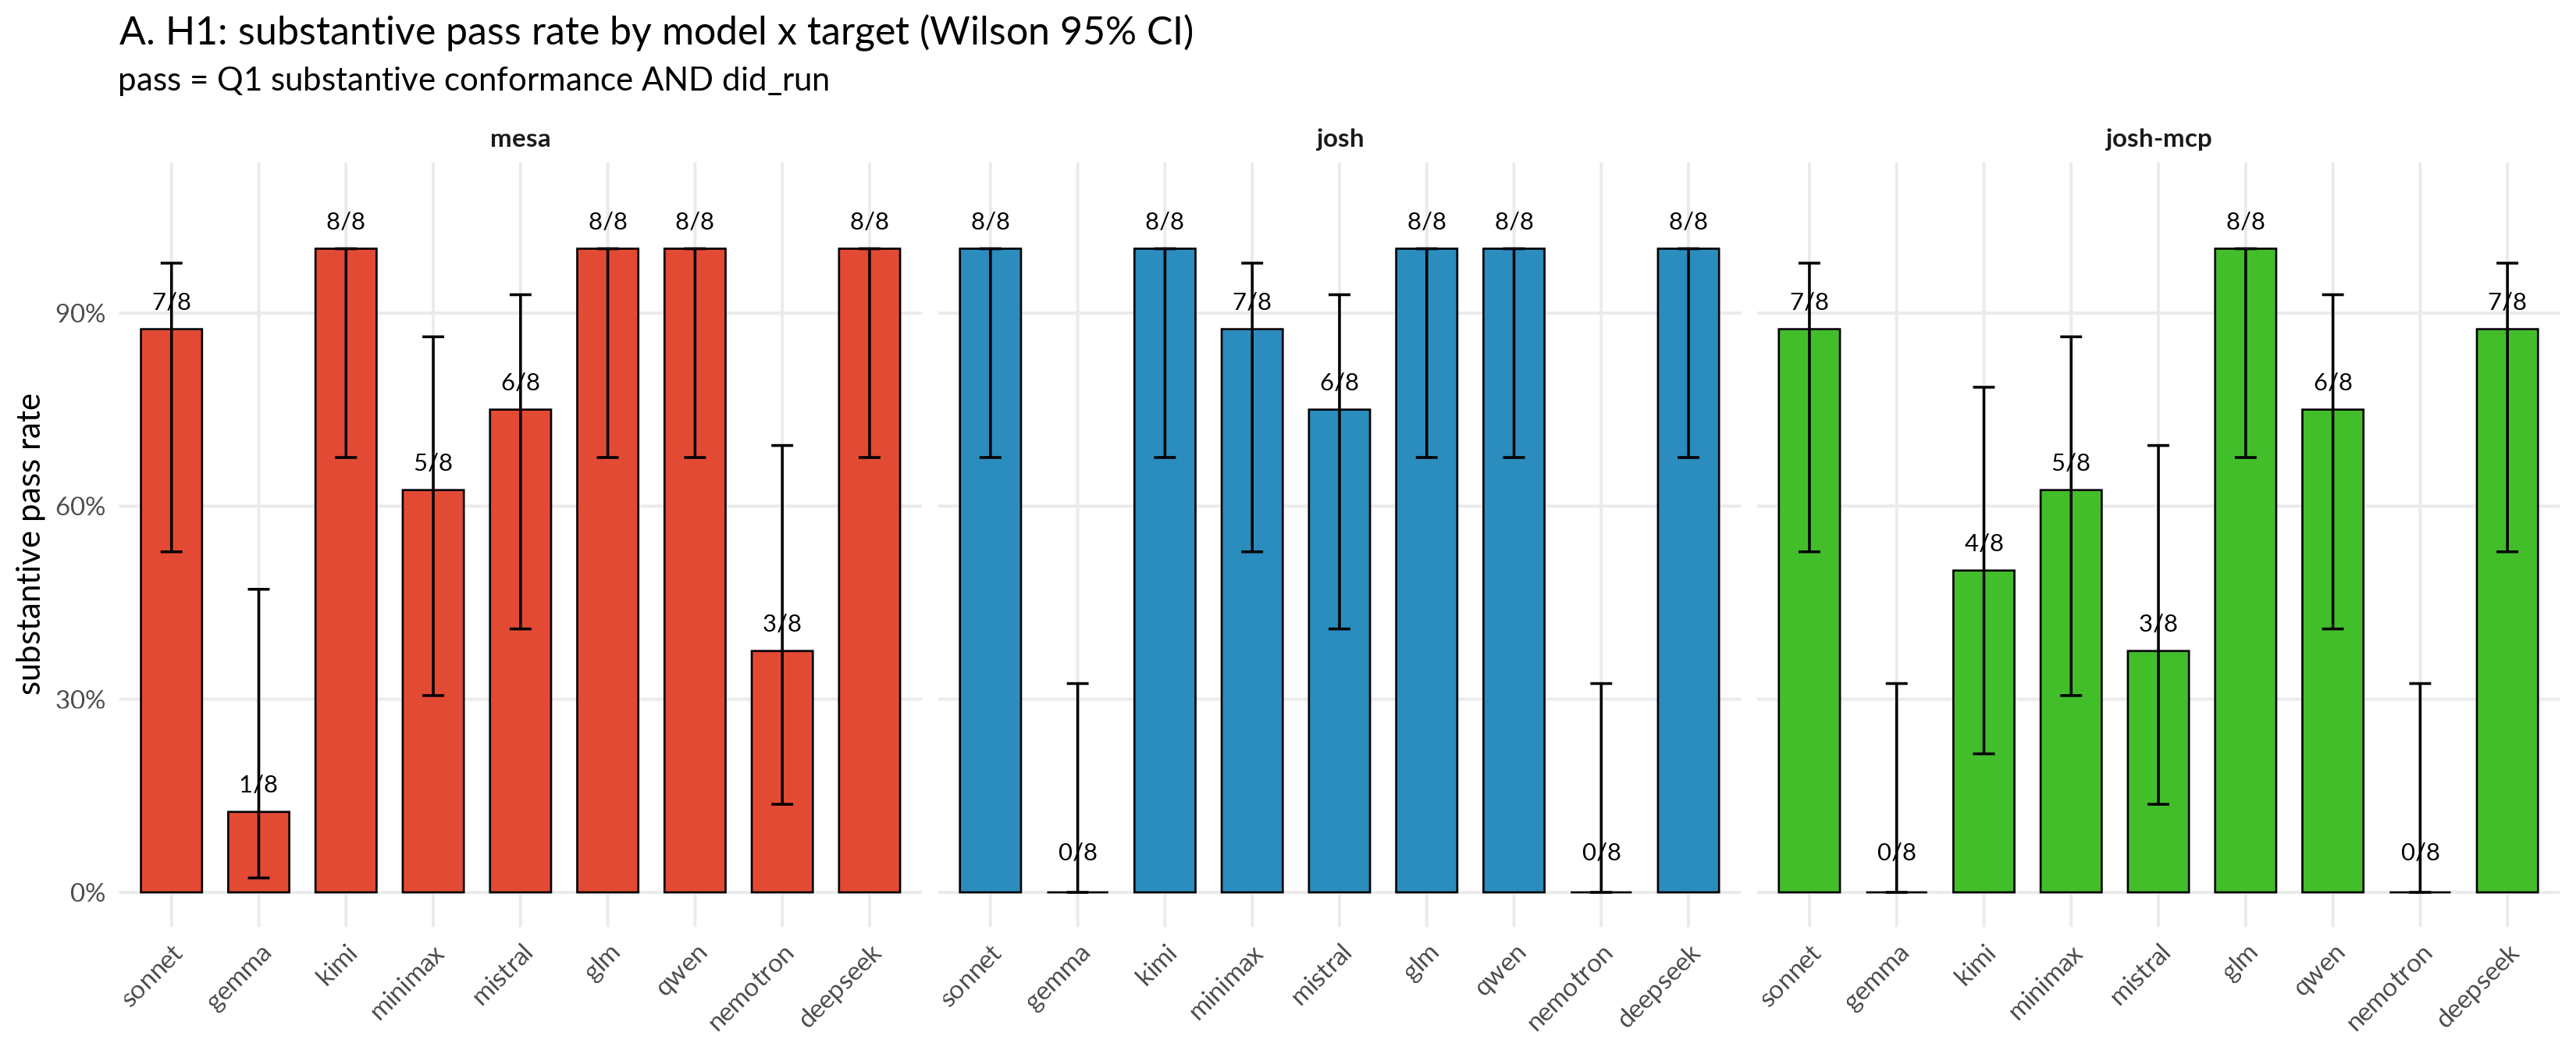

In [6]:
options(repr.plot.width = 11, repr.plot.height = 4.5)

pass_df <- df %>%
  # Exclude synthetic no_scorer rows. After the rescore pass (SCORER_K8S.md),
  # the only no_scorer cells left are provider-throttle (OpenRouter 429 /
  # free-tier lockout) or agent-never-started failures — no scorable work, so
  # excluding them as infra is honest. Cells killed mid-step by the 2 h deadline
  # are re-scored in place to did_run=FALSE and counted here as failures.
  filter(engagement_status != "no_scorer") %>%
  mutate(pass = substantive_conformance & did_run) %>%
  group_by(model, target, .drop = FALSE) %>%
  summarise(k = sum(pass, na.rm = TRUE), n = n(), .groups = "drop") %>%
  rowwise() %>%
  mutate(ci = list(wilson_ci(k, n)),
         phat = ci["point"], lo = ci["lo"], hi = ci["hi"],
         phat = ifelse(is.na(phat), 0, phat),
         label = ifelse(n > 0, sprintf("%d/%d", k, n), "0/0")) %>%
  ungroup()

p_a <- ggplot(pass_df, aes(model, phat, fill = target)) +
  geom_col(width = 0.7, colour = "black", linewidth = 0.3) +
  geom_errorbar(aes(ymin = lo, ymax = hi), width = 0.25, linewidth = 0.4,
                na.rm = TRUE) +
  geom_text(aes(y = pmax(phat + 0.03, 0.05), label = label),
            size = 2.6, vjust = 0) +
  facet_wrap(~ target, nrow = 1) +
  scale_fill_manual(values = TARGET_COLORS, guide = "none") +
  scale_y_continuous(limits = c(0, 1.08), labels = percent_format(accuracy = 1)) +
  labs(title = "A. H1: substantive pass rate by model x target (Wilson 95% CI)",
       subtitle = "pass = Q1 substantive conformance AND did_run",
       x = NULL, y = "substantive pass rate") +
  theme_panel()
p_a
ggsave(file.path(OUT_DIR, "headline_passrate.png"), p_a, width = 11, height = 4.5)
ggsave(file.path(OUT_DIR, "headline_passrate.pdf"), p_a, width = 11, height = 4.5)

## Panel B — 5-axis report card (`facet_grid(model ~ target)`)

The five scoring axes (engagement, conformance, execution, ecology, contract)
per replicate. `facet_grid(model ~ target)` gives one tile-grid per
`(model, target)` cell; within each, axis on the x and one jittered dot per
replicate, coloured by status.

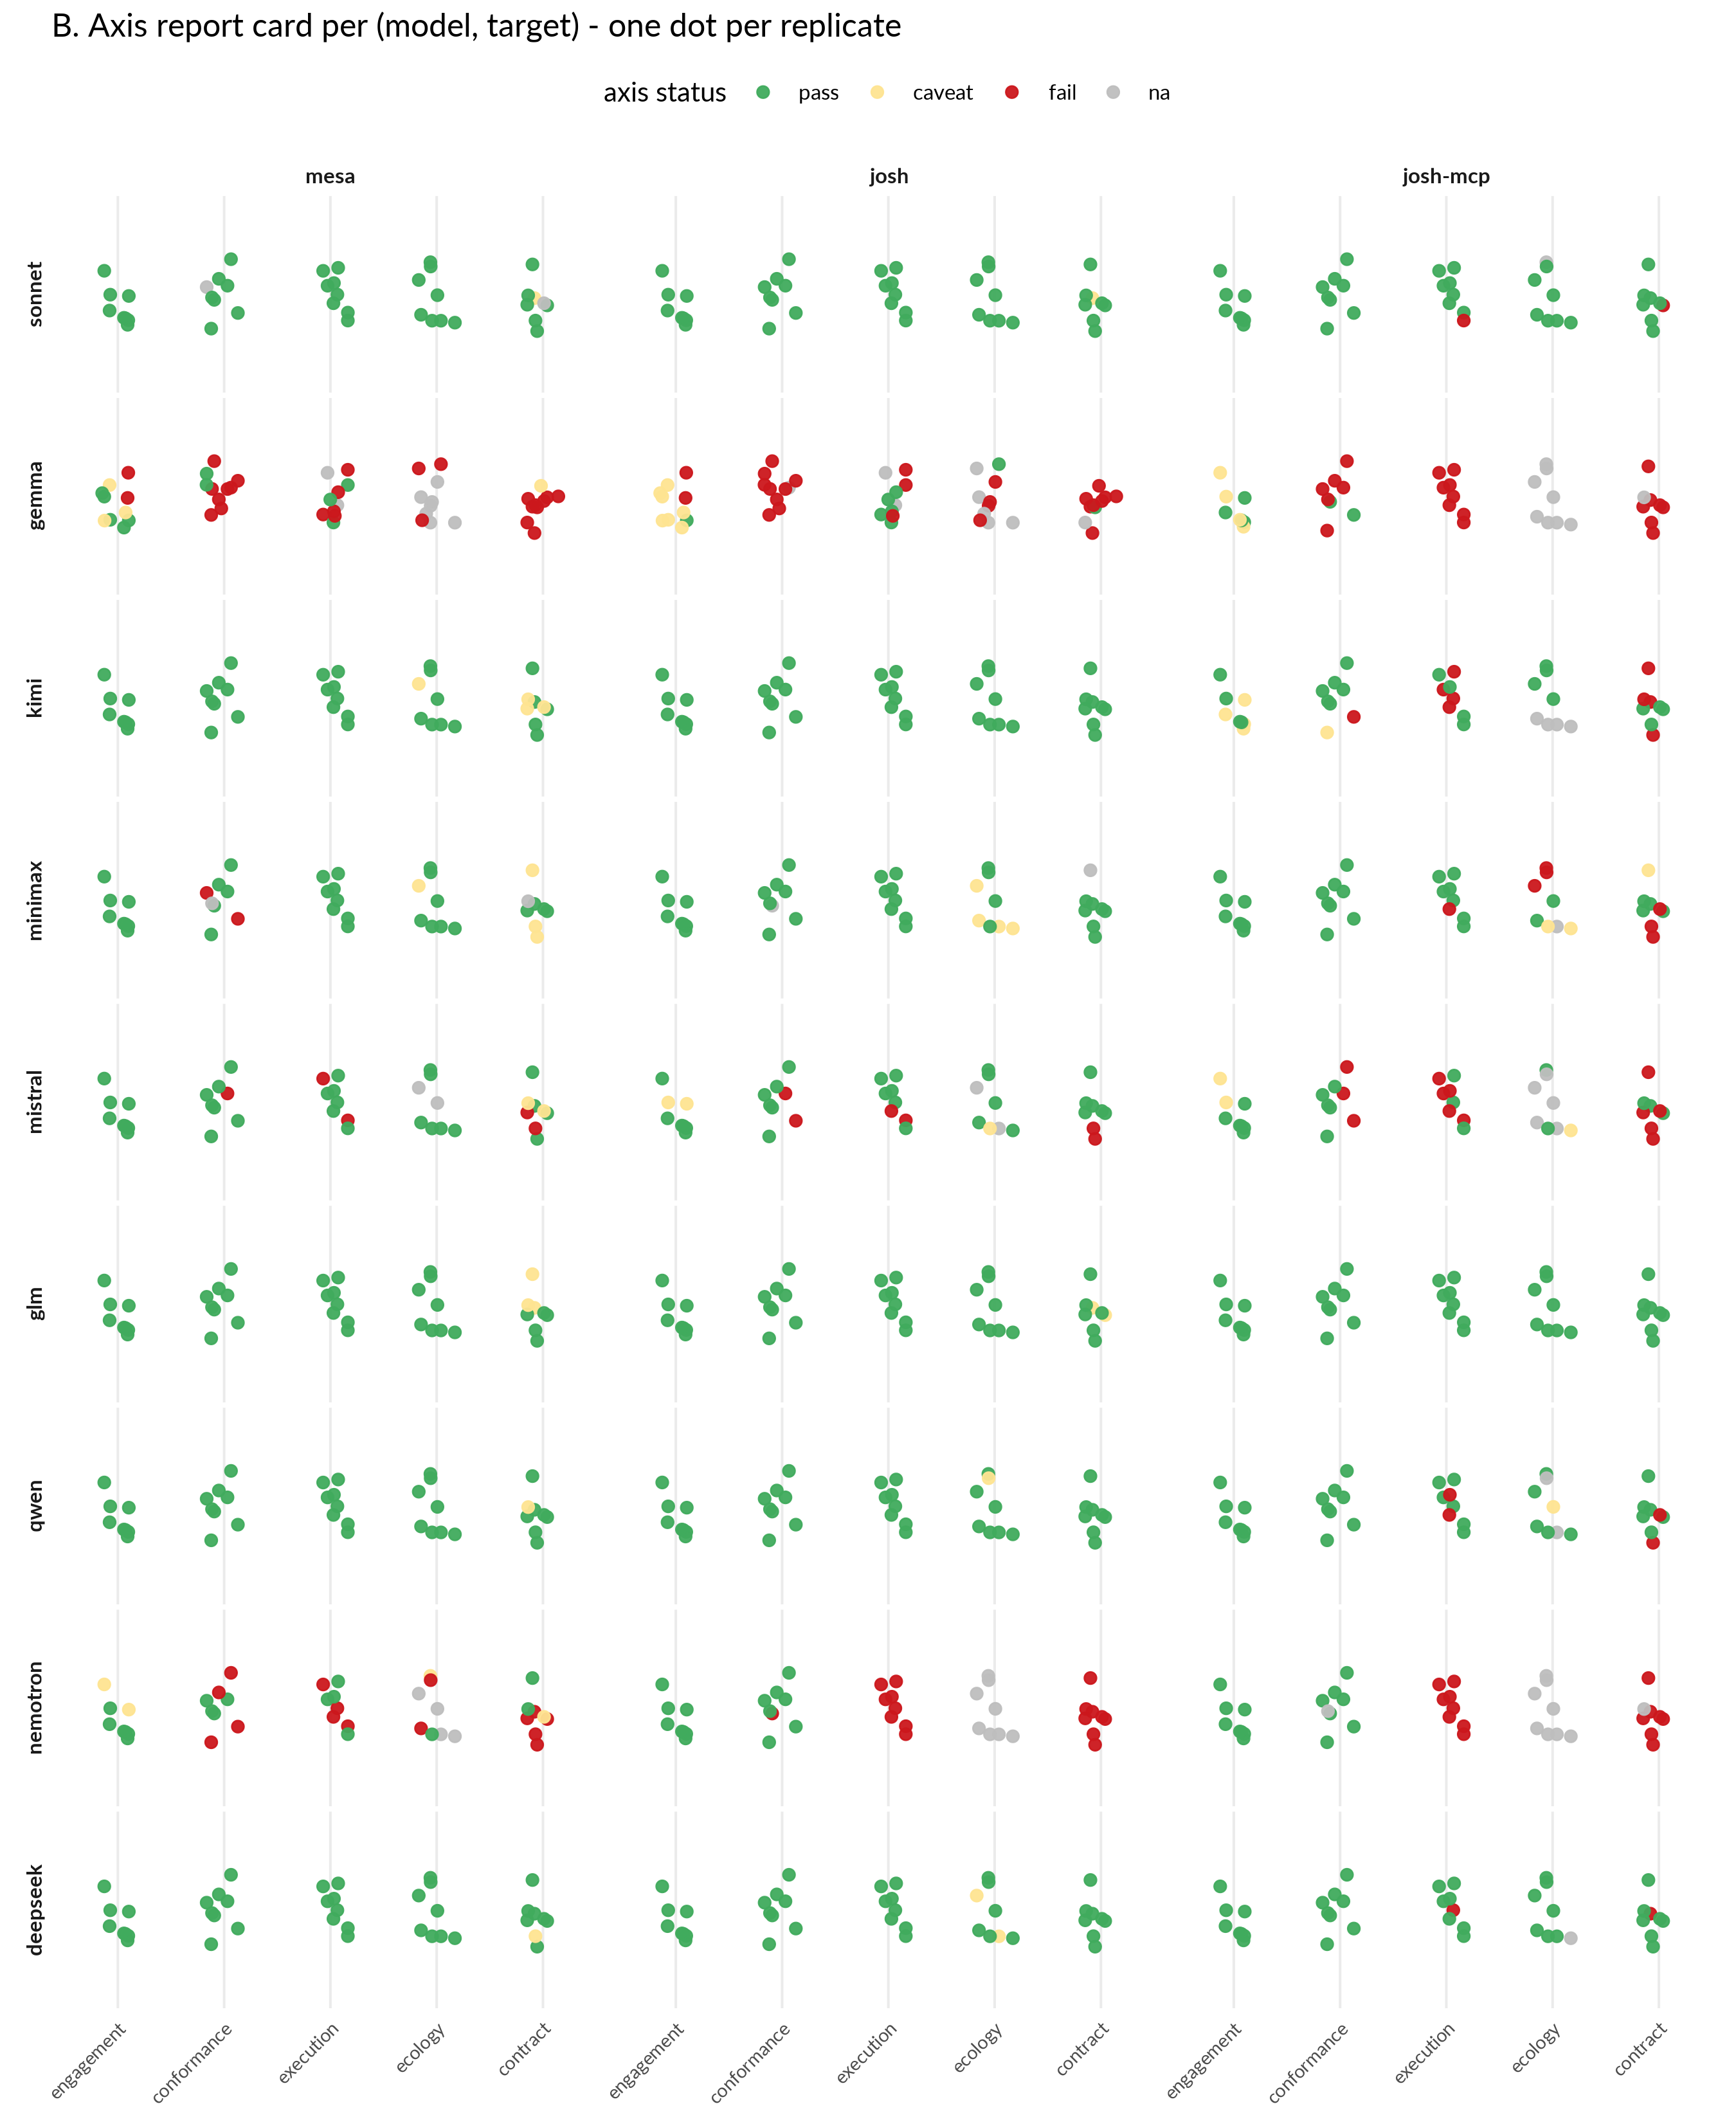

In [7]:
options(repr.plot.width = 9, repr.plot.height = 11)

AXIS_LEVELS <- c("engagement", "conformance", "execution", "ecology", "contract")

axes_long <- df %>%
  select(model, target, rep_idx,
         axis_engagement, axis_conformance, axis_execution,
         axis_ecology, axis_contract) %>%
  pivot_longer(starts_with("axis_"), names_to = "axis", values_to = "status") %>%
  mutate(
    axis   = factor(sub("axis_", "", axis), levels = AXIS_LEVELS),
    status = factor(ifelse(is.na(status) | status == "", "na", status),
                    levels = names(AXIS_STATUS_COLORS))
  )

p_b <- ggplot(axes_long, aes(axis, 0, colour = status)) +
  geom_jitter(width = 0.18, height = 0.25, size = 1.8, alpha = 0.95) +
  facet_grid(model ~ target, switch = "y") +
  scale_colour_manual(values = AXIS_STATUS_COLORS, name = "axis status",
                      drop = FALSE) +
  scale_y_continuous(breaks = NULL, limits = c(-0.6, 0.6)) +
  labs(title = "B. Axis report card per (model, target) - one dot per replicate",
       x = NULL, y = NULL) +
  theme_panel() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
        panel.spacing = unit(2, "pt"))
p_b
ggsave(file.path(OUT_DIR, "headline_axes.png"), p_b, width = 9, height = 11)
ggsave(file.path(OUT_DIR, "headline_axes.pdf"), p_b, width = 9, height = 11)

## Regression-fit panel (`facet_grid(metric ~ target)`)

β, α, R² of the per-cell `observed ~ predicted` fit plus the year-100 mean
height sanity check — `did_run` cells only. Each metric is a facet row with its
own y-scale and acceptance band; the treatment is the facet column.

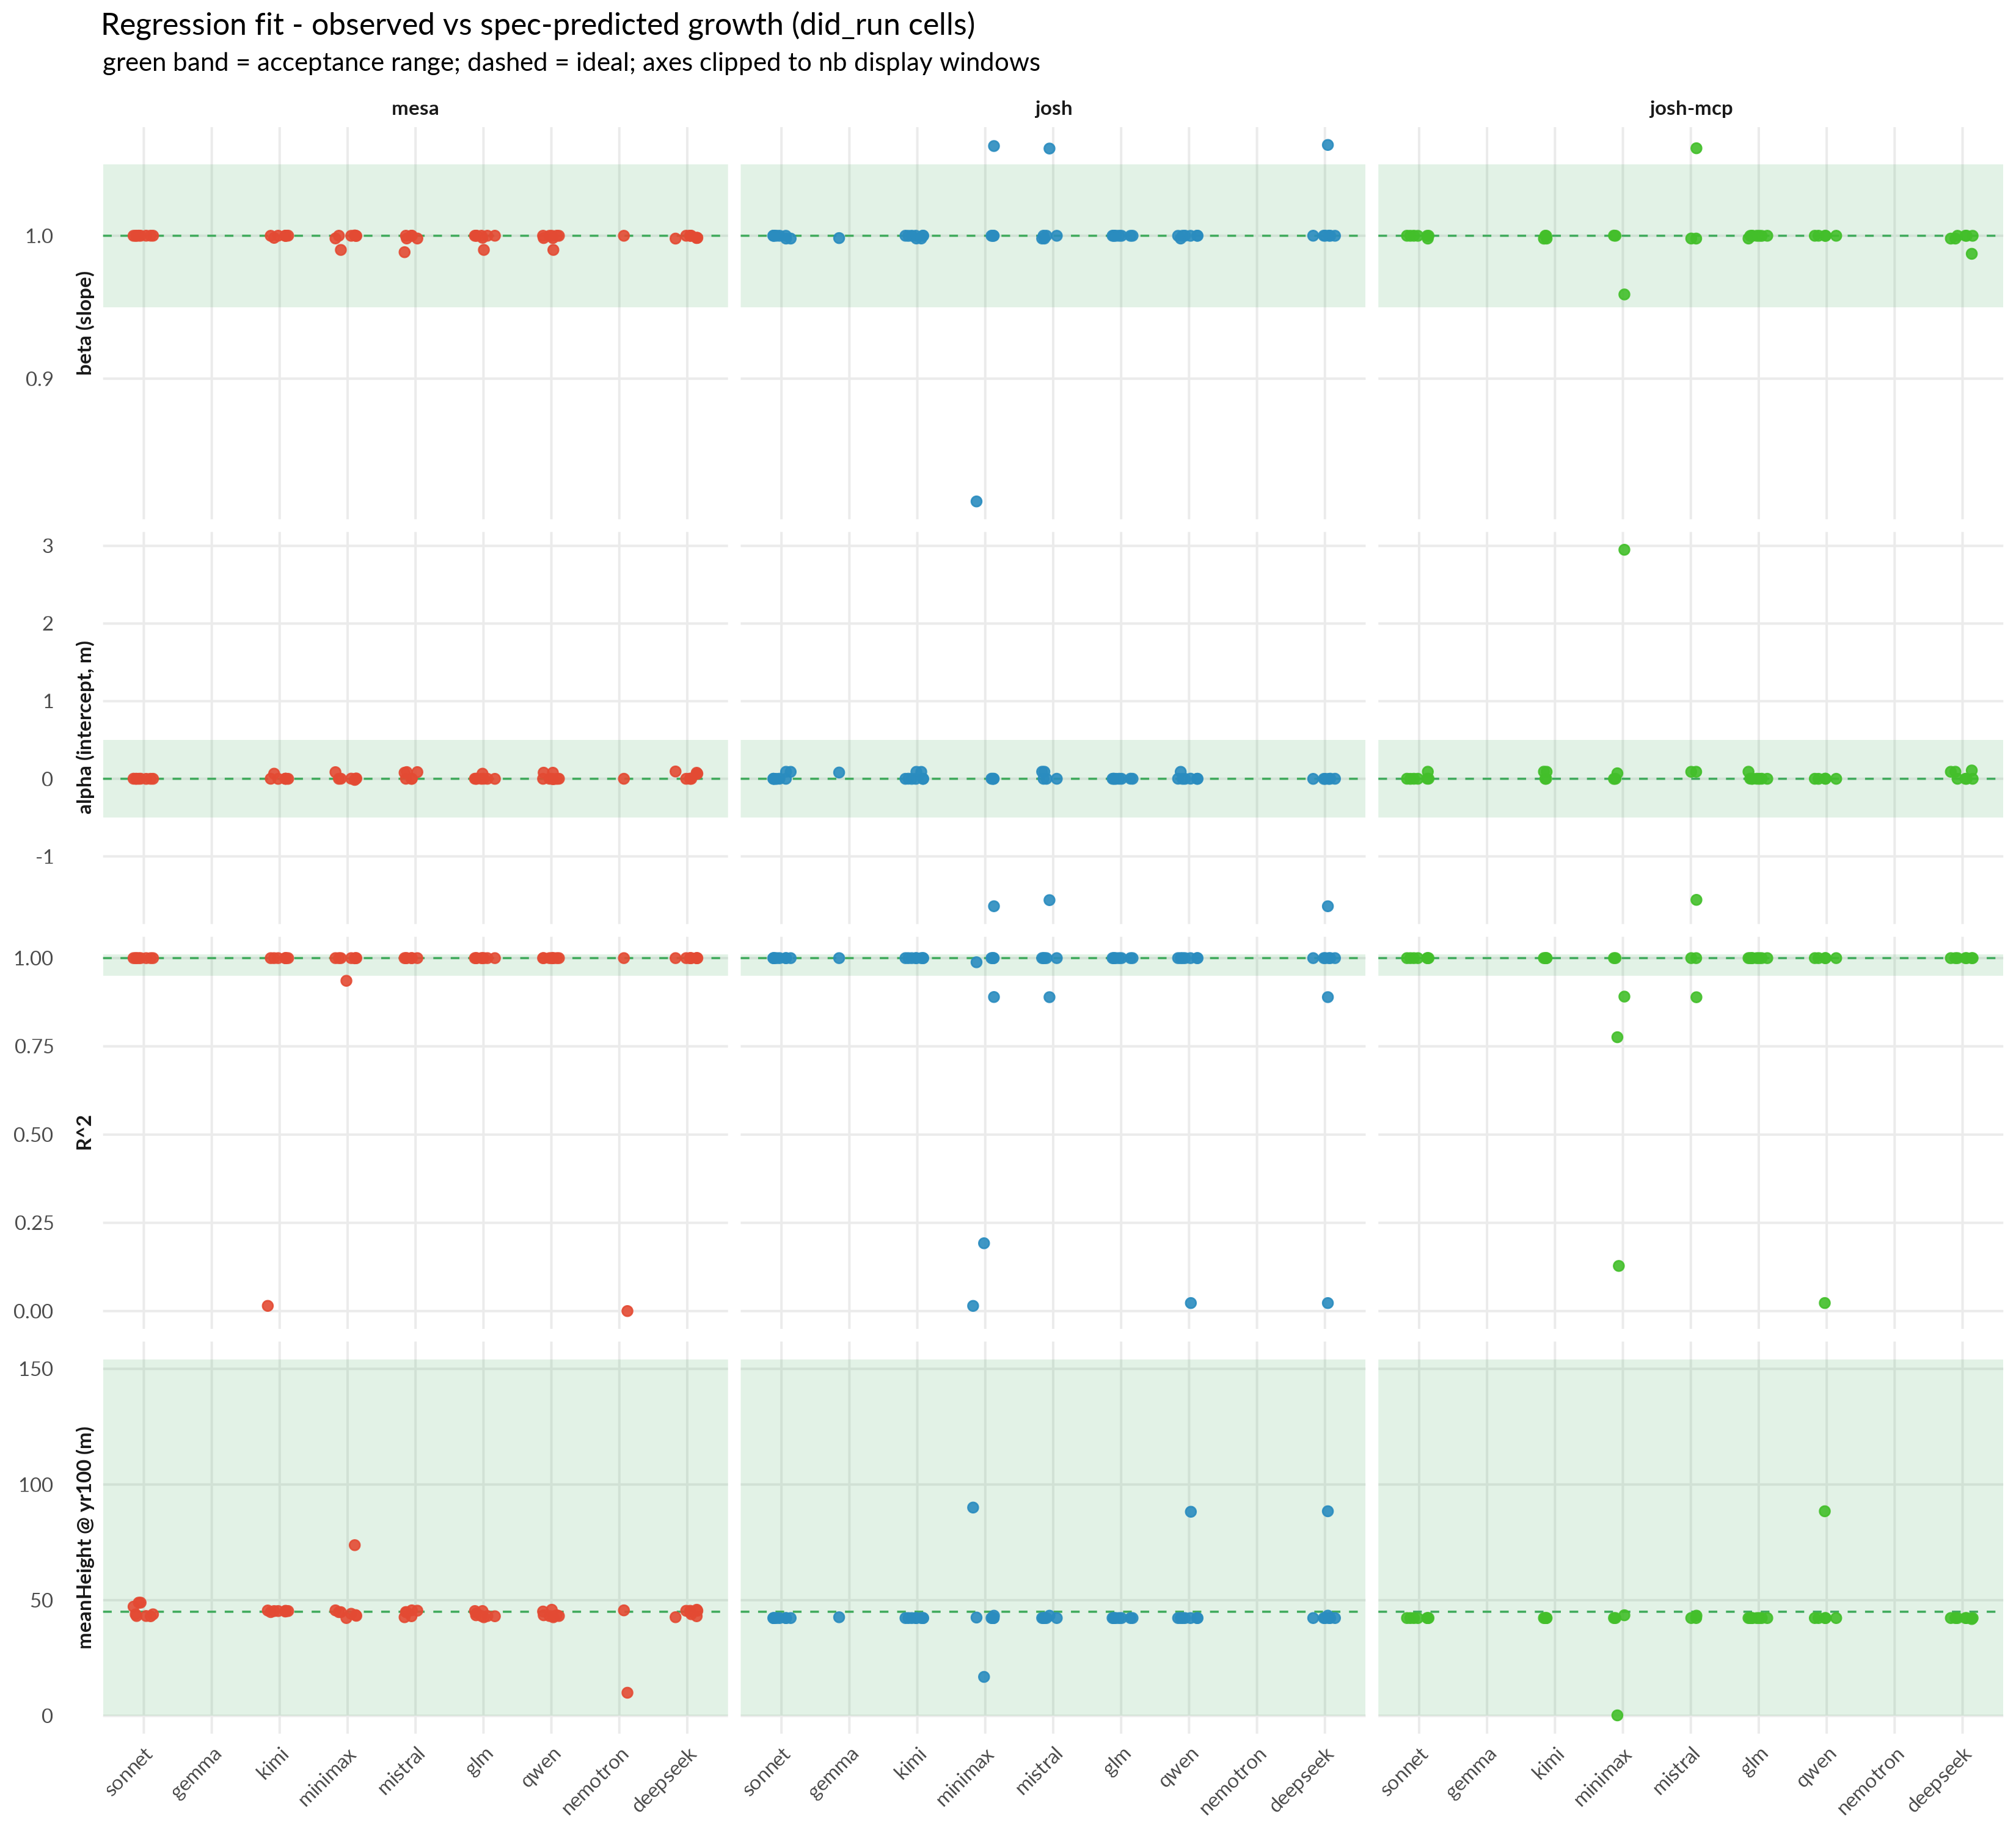

In [8]:
options(repr.plot.width = 11, repr.plot.height = 10)

METRIC_LEVELS <- c("beta", "alpha", "r2", "height")
METRIC_LABELS <- c(beta = "beta (slope)", alpha = "alpha (intercept, m)",
                   r2 = "R^2", height = "meanHeight @ yr100 (m)")

# Per-metric display windows (fixed ylims for the regression metrics).
# Points outside the window are dropped from view so the acceptance band
# stays legible — otherwise a single wild β/R² outlier compresses the panel.
WINDOWS <- tibble::tribble(
  ~metric,  ~win_lo, ~win_hi,
  "beta",    0.6,     1.4,
  "alpha",  -3.0,     3.0,
  "r2",      0.0,     1.05,
  "height", -5.0,   160.0
)

reg_long <- df %>%
  filter(did_run) %>%
  transmute(model, target, rep_idx,
            beta   = regression_beta,
            alpha  = regression_alpha,
            r2     = regression_r2,
            height = height_year100_mean) %>%
  pivot_longer(c(beta, alpha, r2, height),
               names_to = "metric", values_to = "value") %>%
  left_join(WINDOWS, by = "metric") %>%
  mutate(value = ifelse(value < win_lo | value > win_hi, NA_real_, value),
         metric = factor(metric, levels = METRIC_LEVELS,
                         labels = METRIC_LABELS[METRIC_LEVELS]))

# Acceptance bands from harness/acceptance_ranges.json (see nb cell 12).
bands <- tibble::tribble(
  ~metric,  ~lo,   ~hi,      ~ideal,
  "beta",   0.95,  1.05,     1.0,
  "alpha", -0.5,   0.5,      0.0,
  "r2",     0.95,  1.01,     1.0,
  "height", 0.0,   154.0828, 45.0101
) %>%
  mutate(metric = factor(metric, levels = METRIC_LEVELS,
                         labels = METRIC_LABELS[METRIC_LEVELS]))

p_reg <- ggplot(reg_long, aes(model, value, colour = target)) +
  geom_rect(data = bands, inherit.aes = FALSE,
            aes(xmin = -Inf, xmax = Inf, ymin = lo, ymax = hi),
            fill = "#41ab5d", alpha = 0.15) +
  geom_hline(data = bands, aes(yintercept = ideal),
             linetype = "dashed", colour = "#41ab5d", linewidth = 0.4) +
  geom_jitter(width = 0.18, height = 0, size = 1.6, alpha = 0.9,
              na.rm = TRUE) +
  facet_grid(metric ~ target, scales = "free_y", switch = "y") +
  scale_colour_manual(values = TARGET_COLORS, guide = "none") +
  labs(title = "Regression fit - observed vs spec-predicted growth (did_run cells)",
       subtitle = "green band = acceptance range; dashed = ideal; axes clipped to nb display windows",
       x = NULL, y = NULL) +
  theme_panel()
p_reg
ggsave(file.path(OUT_DIR, "regression_ggplot.png"), p_reg, width = 11, height = 10)
ggsave(file.path(OUT_DIR, "regression_ggplot.pdf"), p_reg, width = 11, height = 10)

## Runtime panel (`facet_wrap(~ target)`, log-y)

`sim_wall_seconds` (pure `./run.sh`) on a log scale. Marker fill encodes the Q3
faithfulness contract (filled = Q3-faithful, hollow = Q3 partial/no, triangle =
failed) — see nb cell 14.

Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


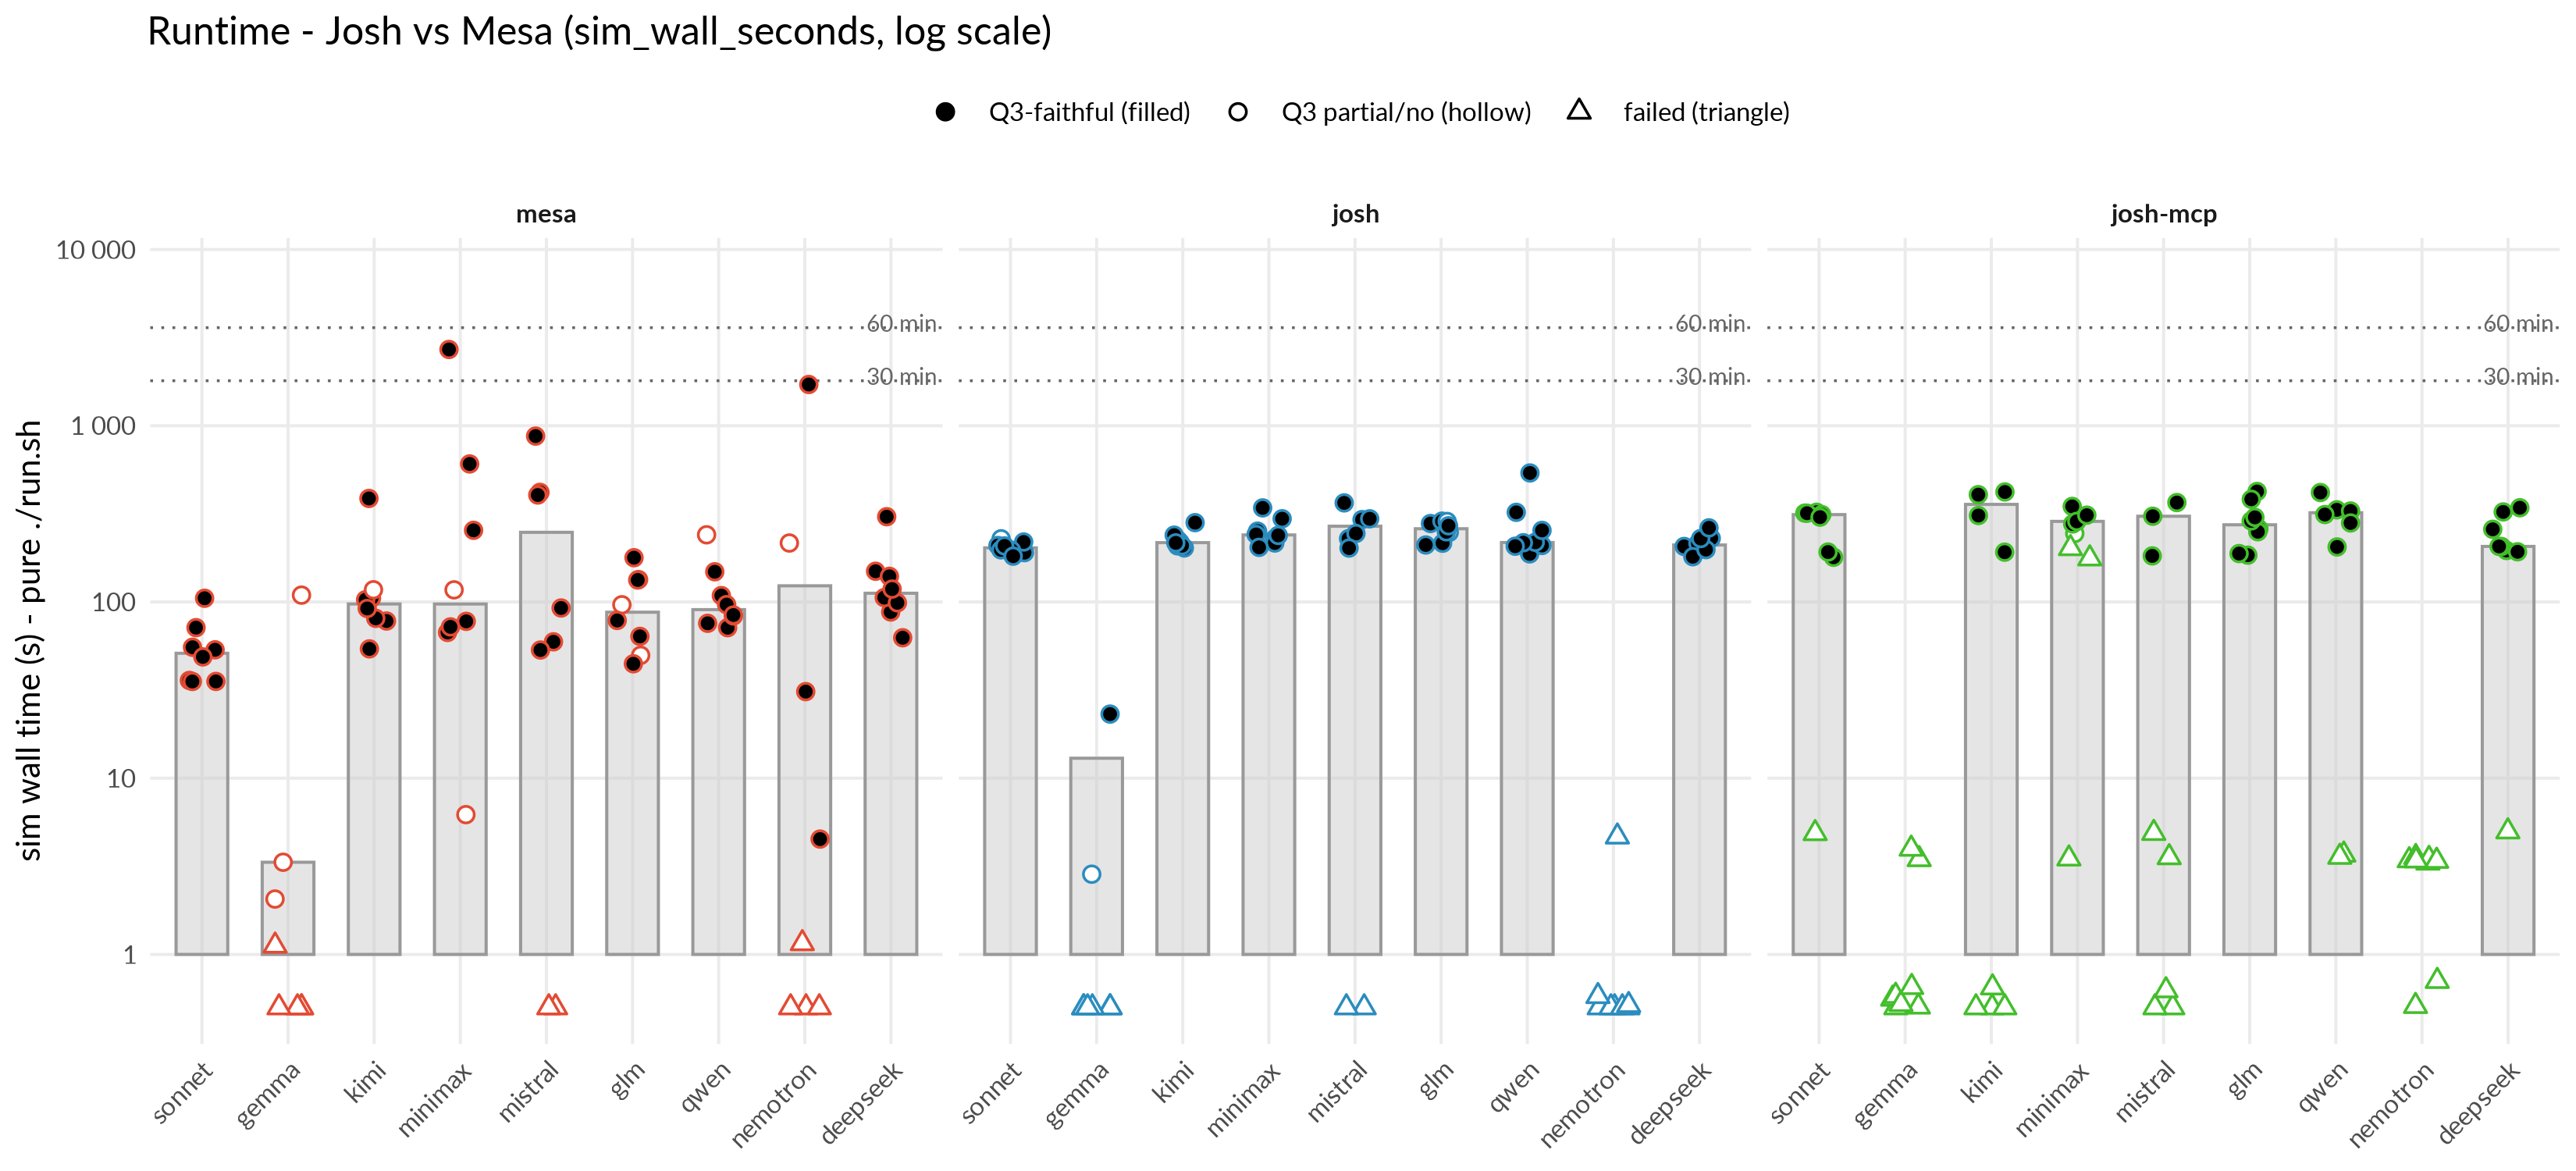

In [9]:
options(repr.plot.width = 11, repr.plot.height = 5)

runtime_df <- df %>%
  mutate(
    run_state = case_when(
      !did_run                              ~ "failed (triangle)",
      fuzzy_q3_answer %in% c("partial", "no") ~ "Q3 partial/no (hollow)",
      TRUE                                  ~ "Q3-faithful (filled)"
    ),
    run_state = factor(run_state,
                       levels = c("Q3-faithful (filled)", "Q3 partial/no (hollow)",
                                  "failed (triangle)")),
    sim_plot = pmax(sim_wall_seconds, 0.5)
  )

# median backdrop bar over did_run cells, per (model, target).
runtime_med <- runtime_df %>%
  filter(did_run) %>%
  group_by(model, target, .drop = FALSE) %>%
  summarise(med = median(sim_wall_seconds, na.rm = TRUE), .groups = "drop") %>%
  filter(!is.na(med))

p_rt <- ggplot(runtime_df, aes(model, sim_plot)) +
  geom_col(data = runtime_med, aes(model, med), inherit.aes = FALSE,
           fill = "grey80", colour = "grey60", width = 0.6, alpha = 0.5) +
  geom_hline(yintercept = c(1800, 3600), linetype = "dotted",
             colour = "grey40", linewidth = 0.4) +
  geom_jitter(aes(colour = target, shape = run_state, fill = run_state),
              width = 0.18, height = 0, size = 2, stroke = 0.6) +
  facet_wrap(~ target, nrow = 1) +
  scale_y_log10(labels = label_number(), limits = c(0.5, 7200)) +
  scale_colour_manual(values = TARGET_COLORS, guide = "none") +
  scale_shape_manual(values = c("Q3-faithful (filled)" = 21,
                                "Q3 partial/no (hollow)" = 21,
                                "failed (triangle)" = 24), name = NULL) +
  scale_fill_manual(values = c("Q3-faithful (filled)" = "black",
                               "Q3 partial/no (hollow)" = "white",
                               "failed (triangle)" = "white"), name = NULL) +
  annotate("text", x = Inf, y = 1900, label = "30 min", hjust = 1.1,
           size = 2.5, colour = "grey40") +
  annotate("text", x = Inf, y = 3800, label = "60 min", hjust = 1.1,
           size = 2.5, colour = "grey40") +
  labs(title = "Runtime - Josh vs Mesa (sim_wall_seconds, log scale)",
       x = NULL, y = "sim wall time (s) - pure ./run.sh") +
  theme_panel()
p_rt
ggsave(file.path(OUT_DIR, "runtime_ggplot.png"), p_rt, width = 11, height = 5)
ggsave(file.path(OUT_DIR, "runtime_ggplot.pdf"), p_rt, width = 11, height = 5)

## Code / style panel (`facet_grid(metric ~ target)`)

Conciseness metrics per cell. Each metric is a facet row (free y-scale),
treatment is the facet column; marker shape encodes `did_run`.

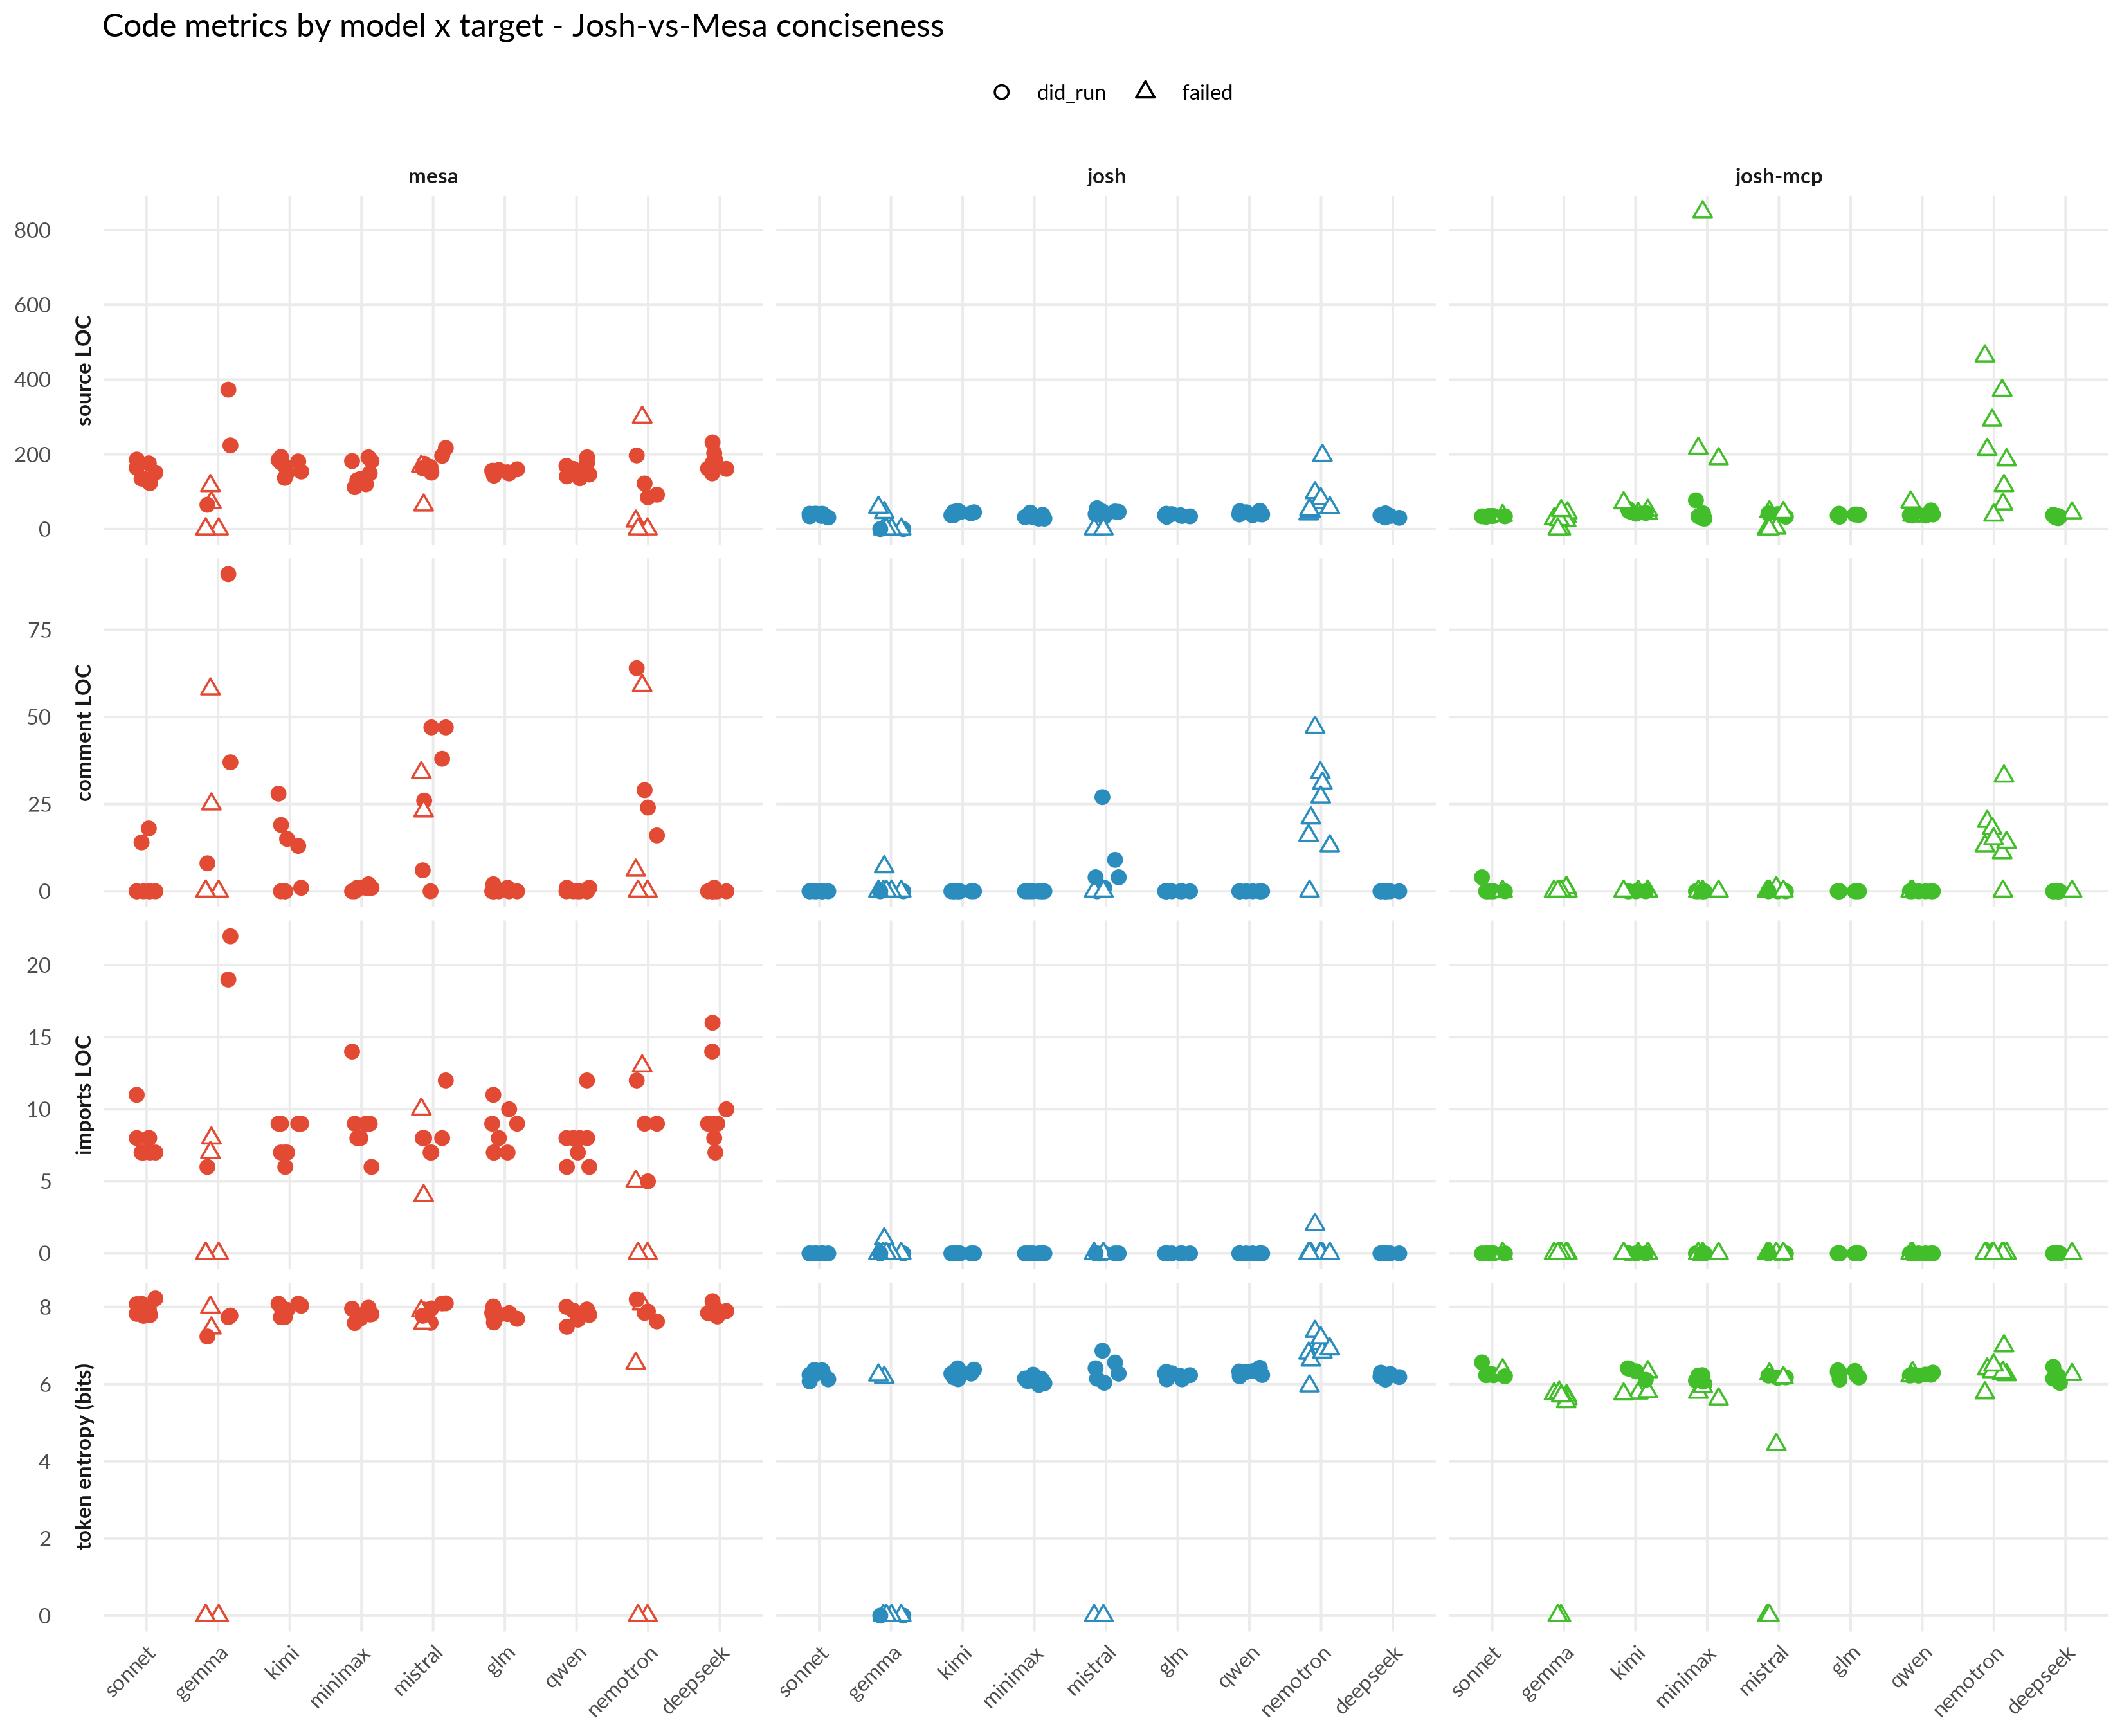

In [10]:
options(repr.plot.width = 11, repr.plot.height = 9)

CODE_LEVELS <- c("src_loc", "comment_loc", "imports_loc", "entropy_bits")
CODE_LABELS <- c(src_loc = "source LOC", comment_loc = "comment LOC",
                 imports_loc = "imports LOC", entropy_bits = "token entropy (bits)")

code_long <- df %>%
  select(model, target, did_run, all_of(CODE_LEVELS)) %>%
  pivot_longer(all_of(CODE_LEVELS), names_to = "metric", values_to = "value") %>%
  mutate(metric = factor(metric, levels = CODE_LEVELS,
                         labels = CODE_LABELS[CODE_LEVELS]),
         run_state = ifelse(did_run, "did_run", "failed"))

p_code <- ggplot(code_long, aes(model, value, colour = target, shape = run_state)) +
  geom_jitter(aes(fill = ifelse(did_run,
                                unname(TARGET_COLORS[as.character(target)]),
                                "white")),
              width = 0.18, height = 0, size = 2, stroke = 0.6, na.rm = TRUE) +
  facet_grid(metric ~ target, scales = "free_y", switch = "y") +
  scale_colour_manual(values = TARGET_COLORS, guide = "none") +
  scale_fill_identity() +
  scale_shape_manual(values = c(did_run = 21, failed = 24), name = NULL) +
  labs(title = "Code metrics by model x target - Josh-vs-Mesa conciseness",
       x = NULL, y = NULL) +
  theme_panel()
p_code
ggsave(file.path(OUT_DIR, "code_ggplot.png"), p_code, width = 11, height = 9)
ggsave(file.path(OUT_DIR, "code_ggplot.pdf"), p_code, width = 11, height = 9)

## Agent cost & activity panel (`facet_grid(metric ~ target)`)

Agent-phase spend and activity, summed across the 8 steps. Token counts are
log-scaled (transformed up front since `facet_grid` shares one transform per
row); the other three are linear.

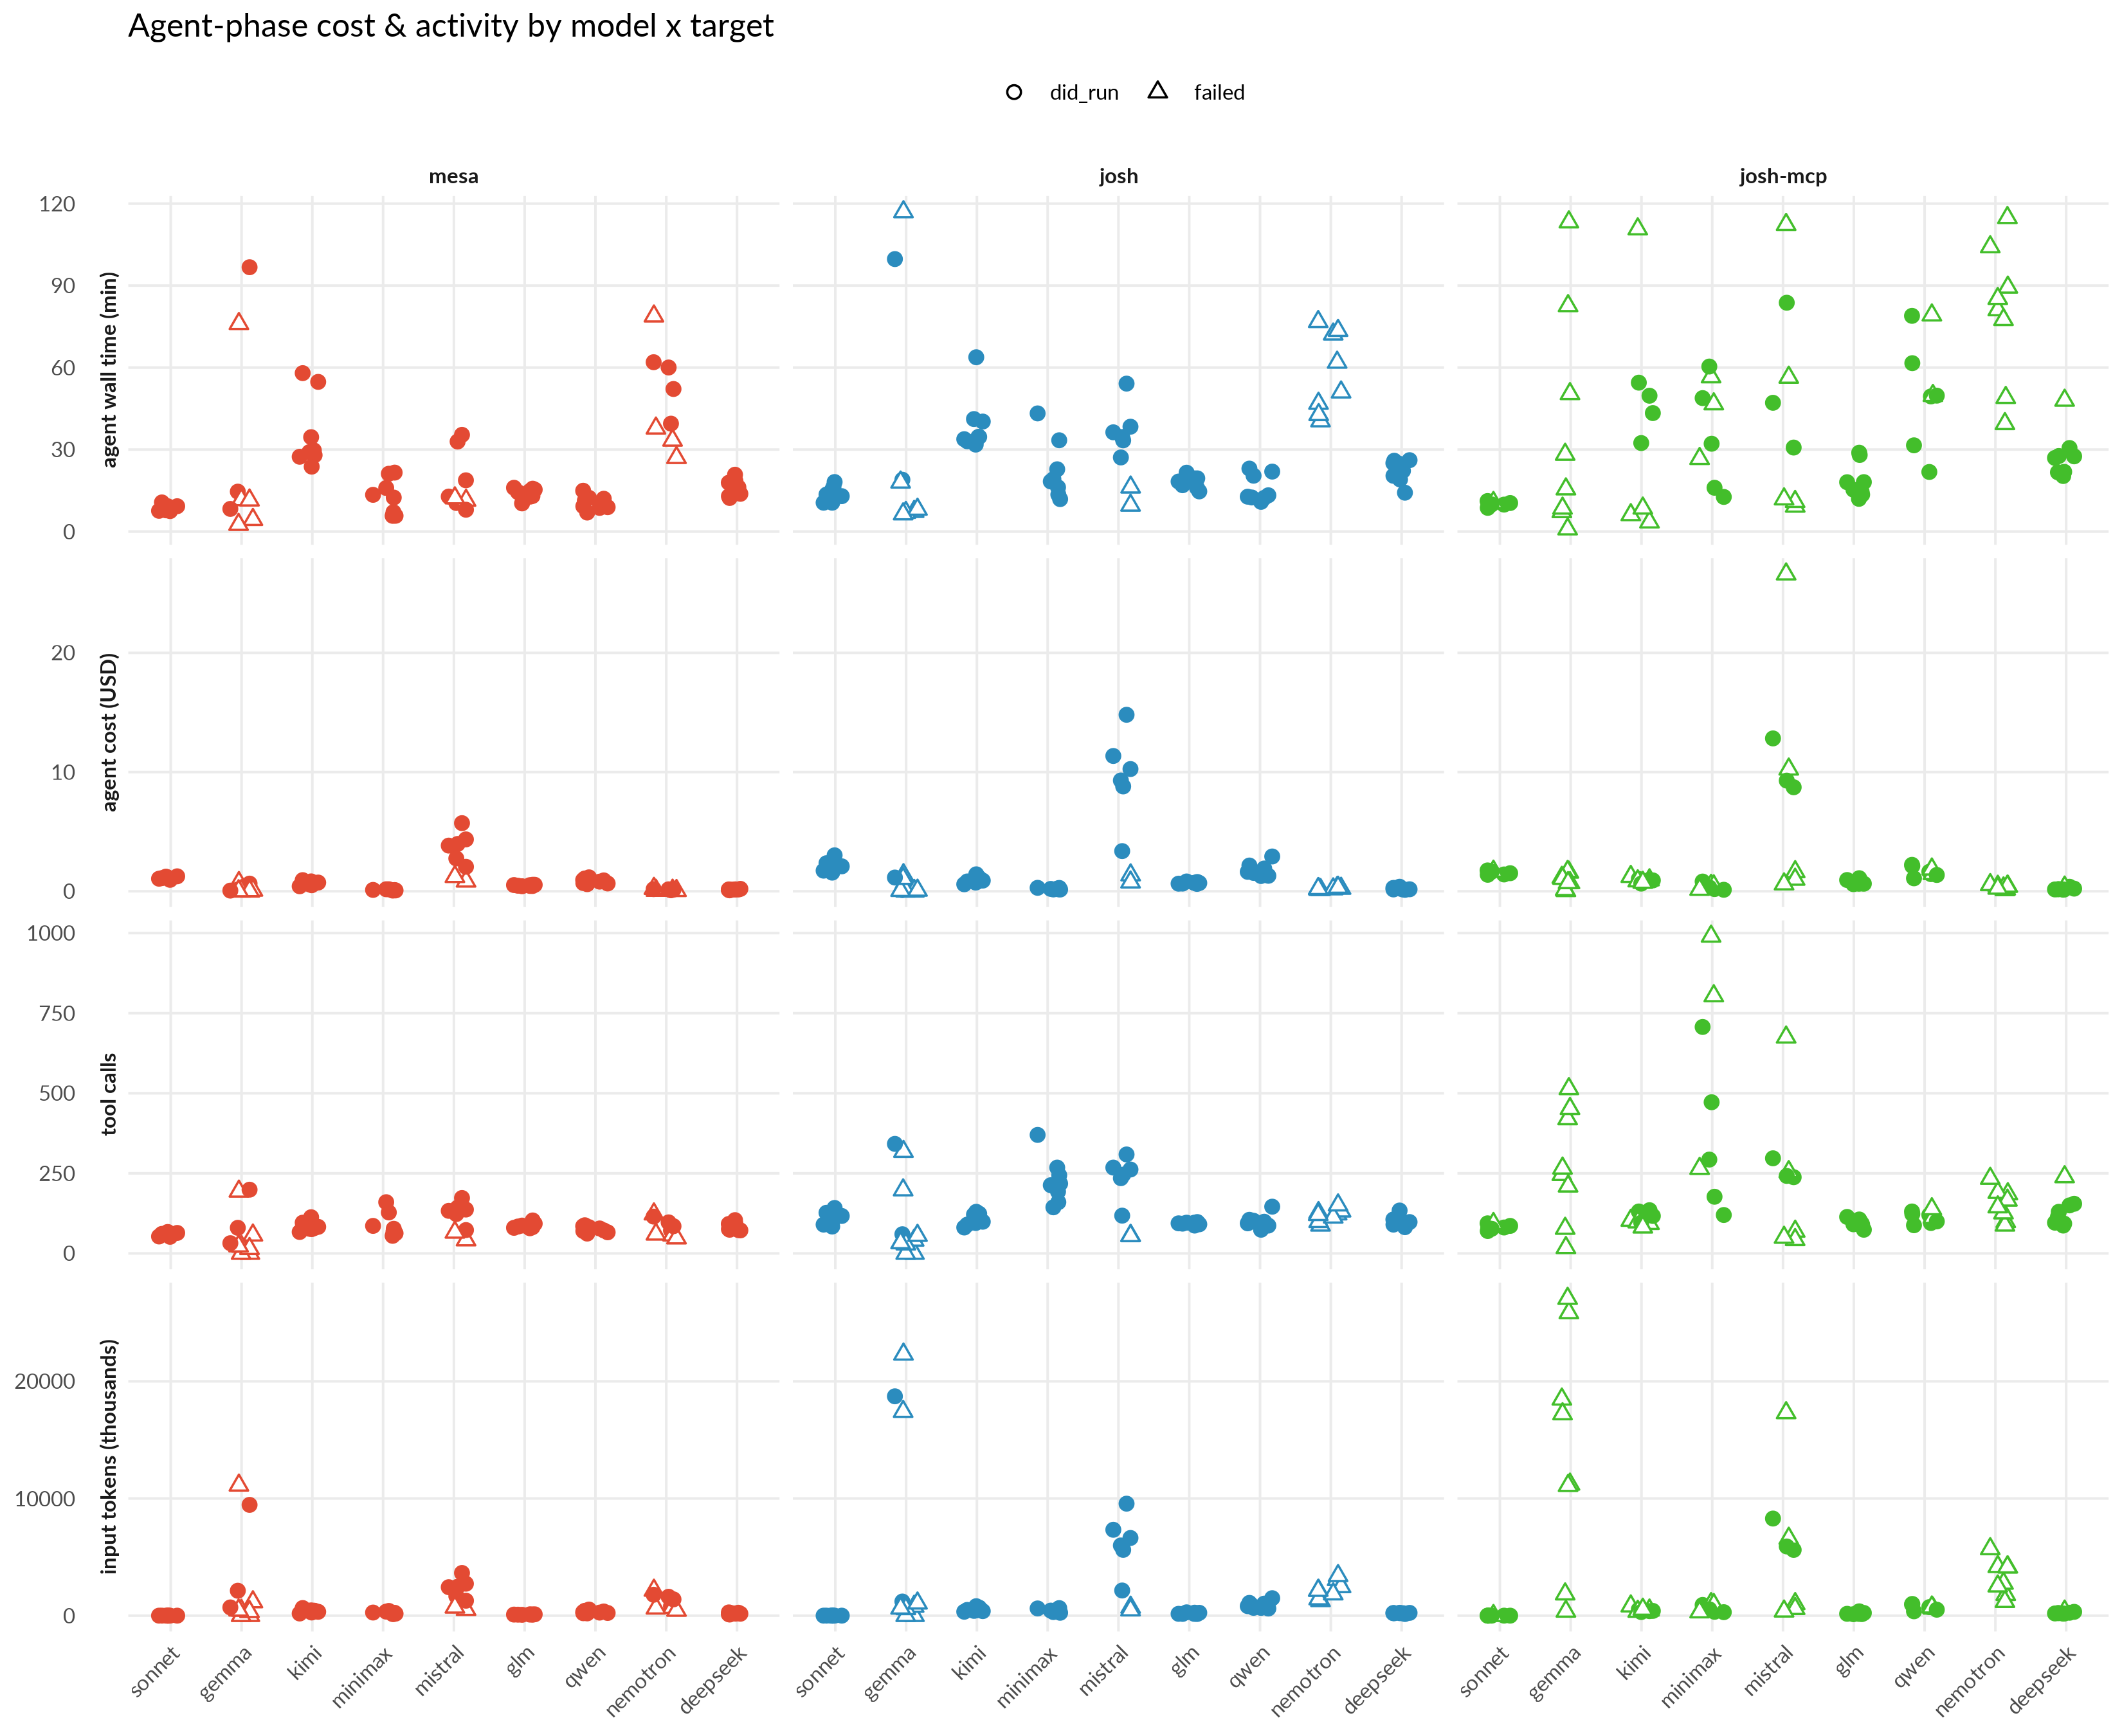

In [11]:
options(repr.plot.width = 11, repr.plot.height = 9)

COST_LEVELS <- c("agent_wall_min", "agent_cost_usd", "agent_tool_calls",
                 "agent_tokens_input_k")
COST_LABELS <- c(agent_wall_min = "agent wall time (min)",
                 agent_cost_usd = "agent cost (USD)",
                 agent_tool_calls = "tool calls",
                 agent_tokens_input_k = "input tokens (thousands)")

cost_long <- df %>%
  transmute(model, target, did_run,
            agent_wall_min       = agent_wall_seconds / 60,
            agent_cost_usd       = agent_cost_usd,
            agent_tool_calls     = agent_tool_calls,
            agent_tokens_input_k = agent_tokens_input / 1000) %>%
  pivot_longer(all_of(COST_LEVELS), names_to = "metric", values_to = "value") %>%
  mutate(metric = factor(metric, levels = COST_LEVELS,
                         labels = COST_LABELS[COST_LEVELS]),
         run_state = ifelse(did_run, "did_run", "failed"))

p_cost <- ggplot(cost_long, aes(model, value, colour = target, shape = run_state)) +
  geom_jitter(aes(fill = ifelse(did_run,
                                unname(TARGET_COLORS[as.character(target)]),
                                "white")),
              width = 0.18, height = 0, size = 2, stroke = 0.6, na.rm = TRUE) +
  facet_grid(metric ~ target, scales = "free_y", switch = "y") +
  scale_colour_manual(values = TARGET_COLORS, guide = "none") +
  scale_fill_identity() +
  scale_shape_manual(values = c(did_run = 21, failed = 24), name = NULL) +
  labs(title = "Agent-phase cost & activity by model x target",
       x = NULL, y = NULL) +
  theme_panel()
p_cost
ggsave(file.path(OUT_DIR, "cost_ggplot.png"), p_cost, width = 11, height = 9)
ggsave(file.path(OUT_DIR, "cost_ggplot.pdf"), p_cost, width = 11, height = 9)

In [12]:
# Whole-batch agent-phase + sim rollup (BATCH TOTAL).
cat(sprintf(
  "BATCH TOTAL: $%.2f | %.1f agent-hours | %.0f sim-seconds | %d tool calls\n",
  sum(df$agent_cost_usd,    na.rm = TRUE),
  sum(df$agent_wall_seconds, na.rm = TRUE) / 3600,
  sum(df$sim_wall_seconds,  na.rm = TRUE),
  as.integer(sum(df$agent_tool_calls, na.rm = TRUE))
))


BATCH TOTAL: $292.14 | 106.4 agent-hours | 37076 sim-seconds | 28872 tool calls


## Tool-use taxonomy — how each arm spent its action budget

Every agent tool call bucketed by *intent* (see `_classify_tool_call` in [aggregate.py](../analysis/aggregate.py)), averaged per cell. The **bash-only** facet — `arbitrary_exec` (run python / scratch scripts), `shell_compute` (awk/wc/sort), `env_introspect` (`--help`/`--version`/`which`) — is capability the constrained **josh-mcp** arm (`bash:false`) has **no equivalent for**: those bars are zero. Reading is *not* a bash advantage (josh-mcp `read`s the most); the MCP arm instead spends its budget on **more edits + model runs** (rewrite-and-rerun guess-and-check). Note the josh (DSL) arm reaches for arbitrary code + CLI probing far more than mesa — the unfamiliar language drives more native-tongue experimentation. *Heuristic taxonomy; descriptive, not a security audit.*

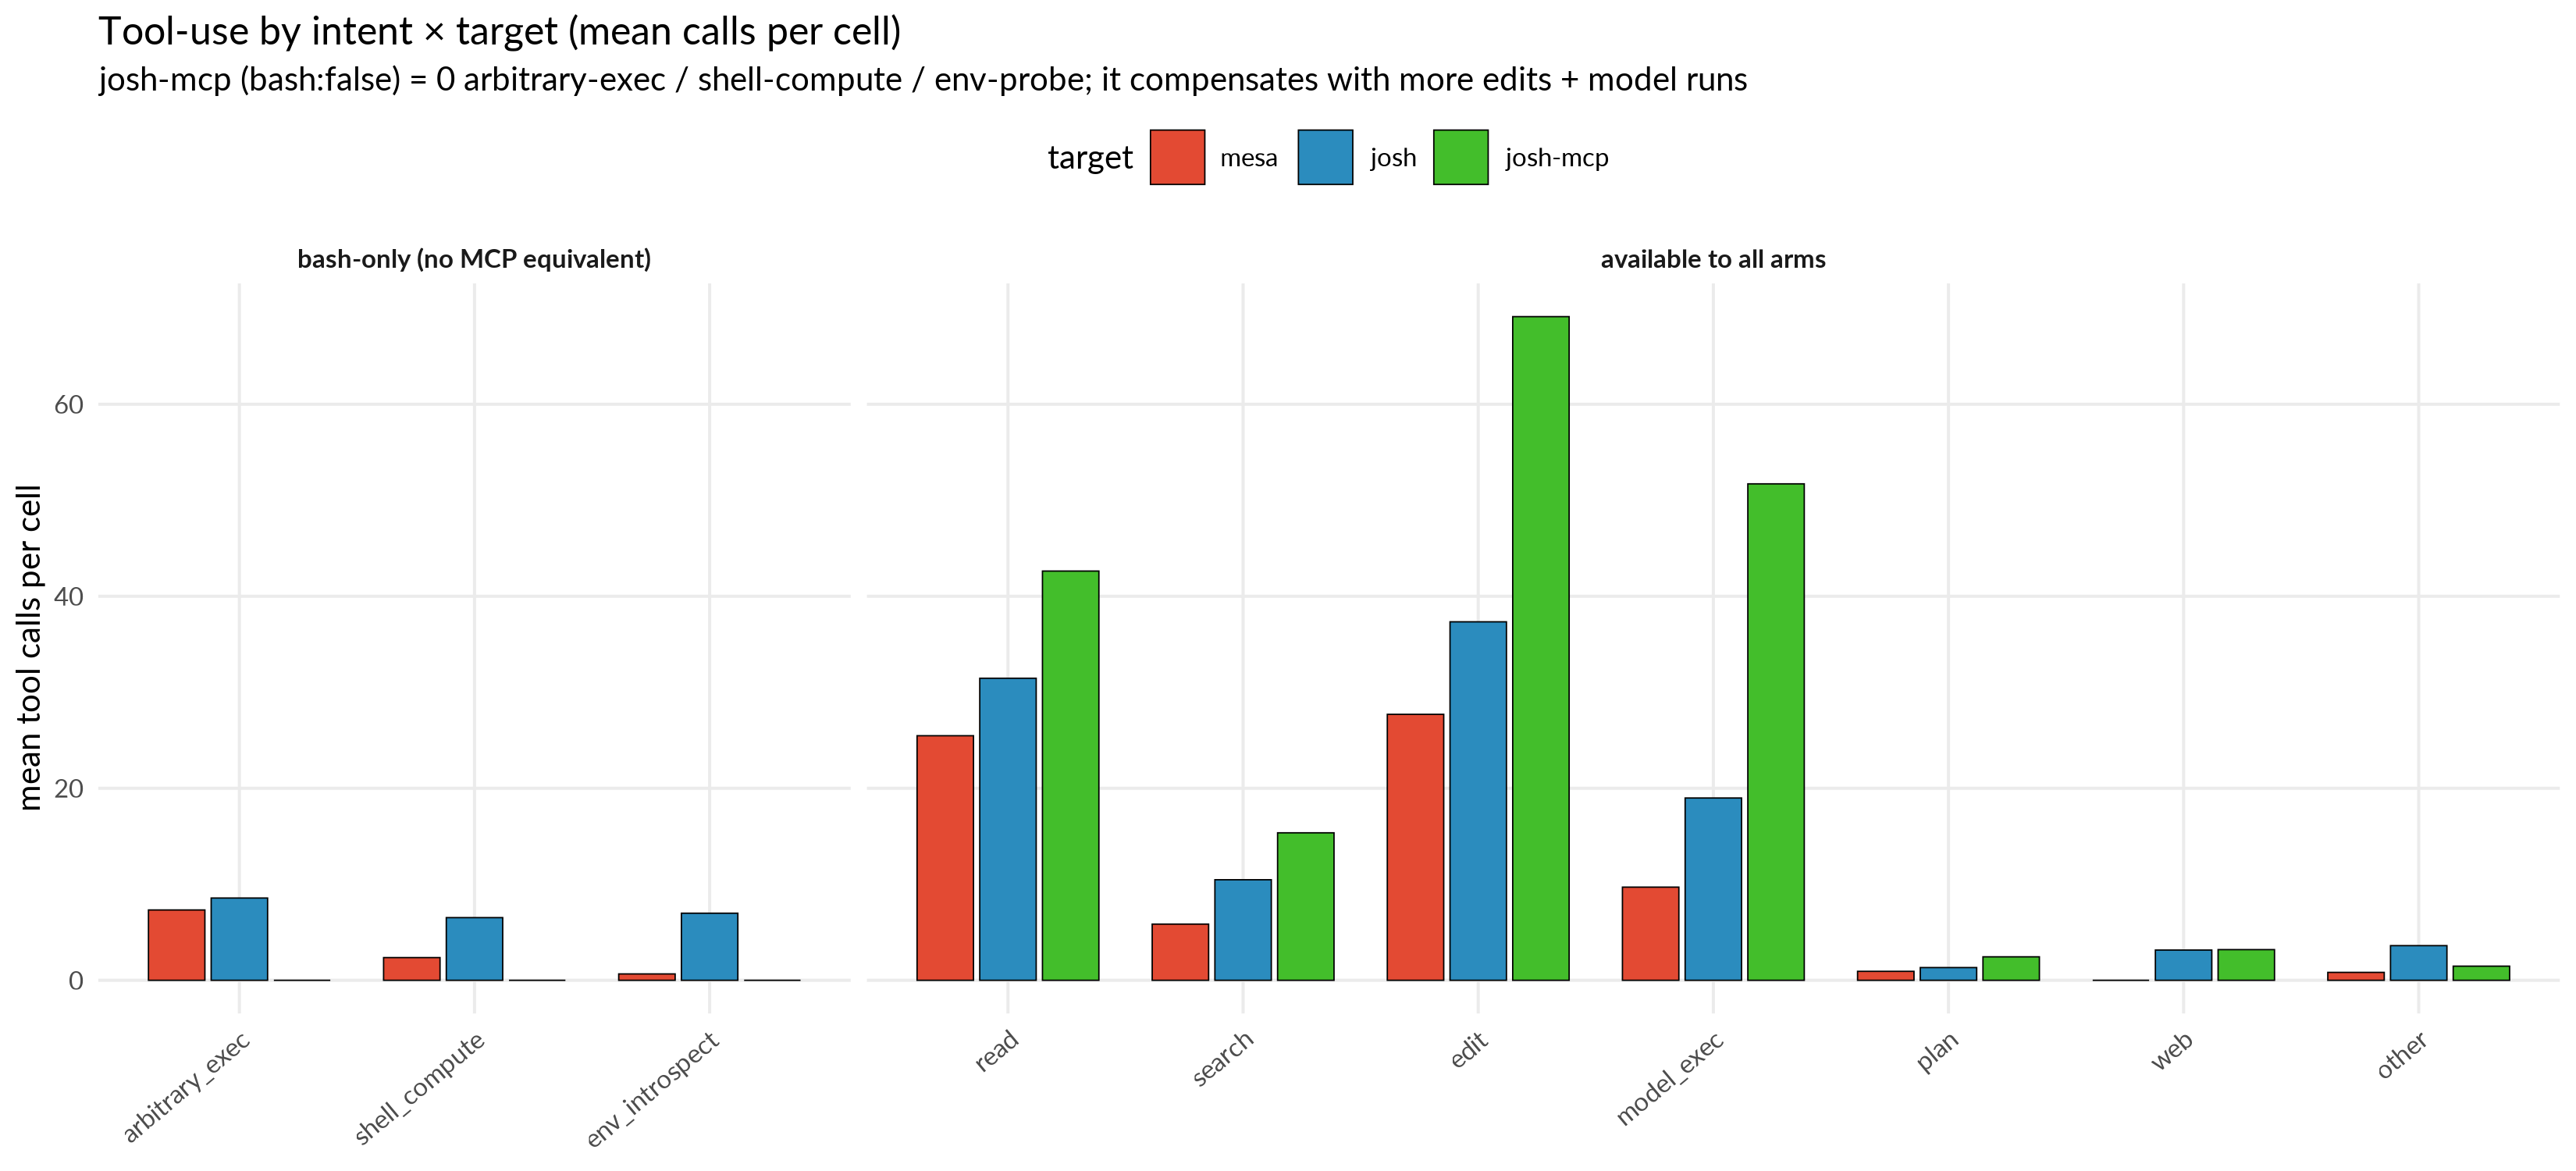

In [13]:
options(repr.plot.width = 11, repr.plot.height = 5)

TOOLCATS  <- c("read", "search", "edit", "model_exec", "arbitrary_exec",
               "shell_compute", "env_introspect", "plan", "web", "other")
BASH_ONLY <- c("arbitrary_exec", "shell_compute", "env_introspect")

tool_long <- df %>%
  select(target, all_of(paste0("toolcat_", TOOLCATS))) %>%
  pivot_longer(starts_with("toolcat_"), names_to = "category",
               values_to = "n", names_prefix = "toolcat_") %>%
  group_by(target, category) %>%
  summarise(mean_calls = mean(n, na.rm = TRUE), .groups = "drop") %>%
  mutate(
    target     = factor(target, levels = TARGET_ORDER),
    category   = factor(category, levels = TOOLCATS),
    capability = factor(ifelse(category %in% BASH_ONLY,
                               "bash-only (no MCP equivalent)",
                               "available to all arms"),
                        levels = c("bash-only (no MCP equivalent)", "available to all arms"))
  )

p_tools <- ggplot(tool_long, aes(category, mean_calls, fill = target)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.72,
           colour = "black", linewidth = 0.2) +
  facet_grid(. ~ capability, scales = "free_x", space = "free_x") +
  scale_fill_manual(values = TARGET_COLORS) +
  labs(title = "Tool-use by intent \u00d7 target (mean calls per cell)",
       subtitle = "josh-mcp (bash:false) = 0 arbitrary-exec / shell-compute / env-probe; it compensates with more edits + model runs",
       x = NULL, y = "mean tool calls per cell", fill = "target") +
  theme_panel() +
  theme(axis.text.x = element_text(angle = 40, hjust = 1))
p_tools
ggsave(file.path(OUT_DIR, "tooluse_ggplot.png"), p_tools, width = 11, height = 5)
ggsave(file.path(OUT_DIR, "tooluse_ggplot.pdf"), p_tools, width = 11, height = 5)


## Documentation dependence — who reaches for the Josh docs

Companion to the tool-use taxonomy. Both Josh arms are pointed at a single
documentation URL (`…/dev/llms-full.txt`, see `prompts/targets/josh*.md`); the
mesa prompt points at `mesa.readthedocs.io`. `fetched_llms_full` (per-cell
boolean in `aggregate.py::_sum_step_exports`) records whether the agent
webfetched `llms-full.txt` at least once. The split is stark: the mesa arm
**never** fetches a doc page — Mesa is in-distribution for these models — while
~80% of Josh / josh-mcp cells pull the Josh docs. Denominator = cells where the
agent ran.

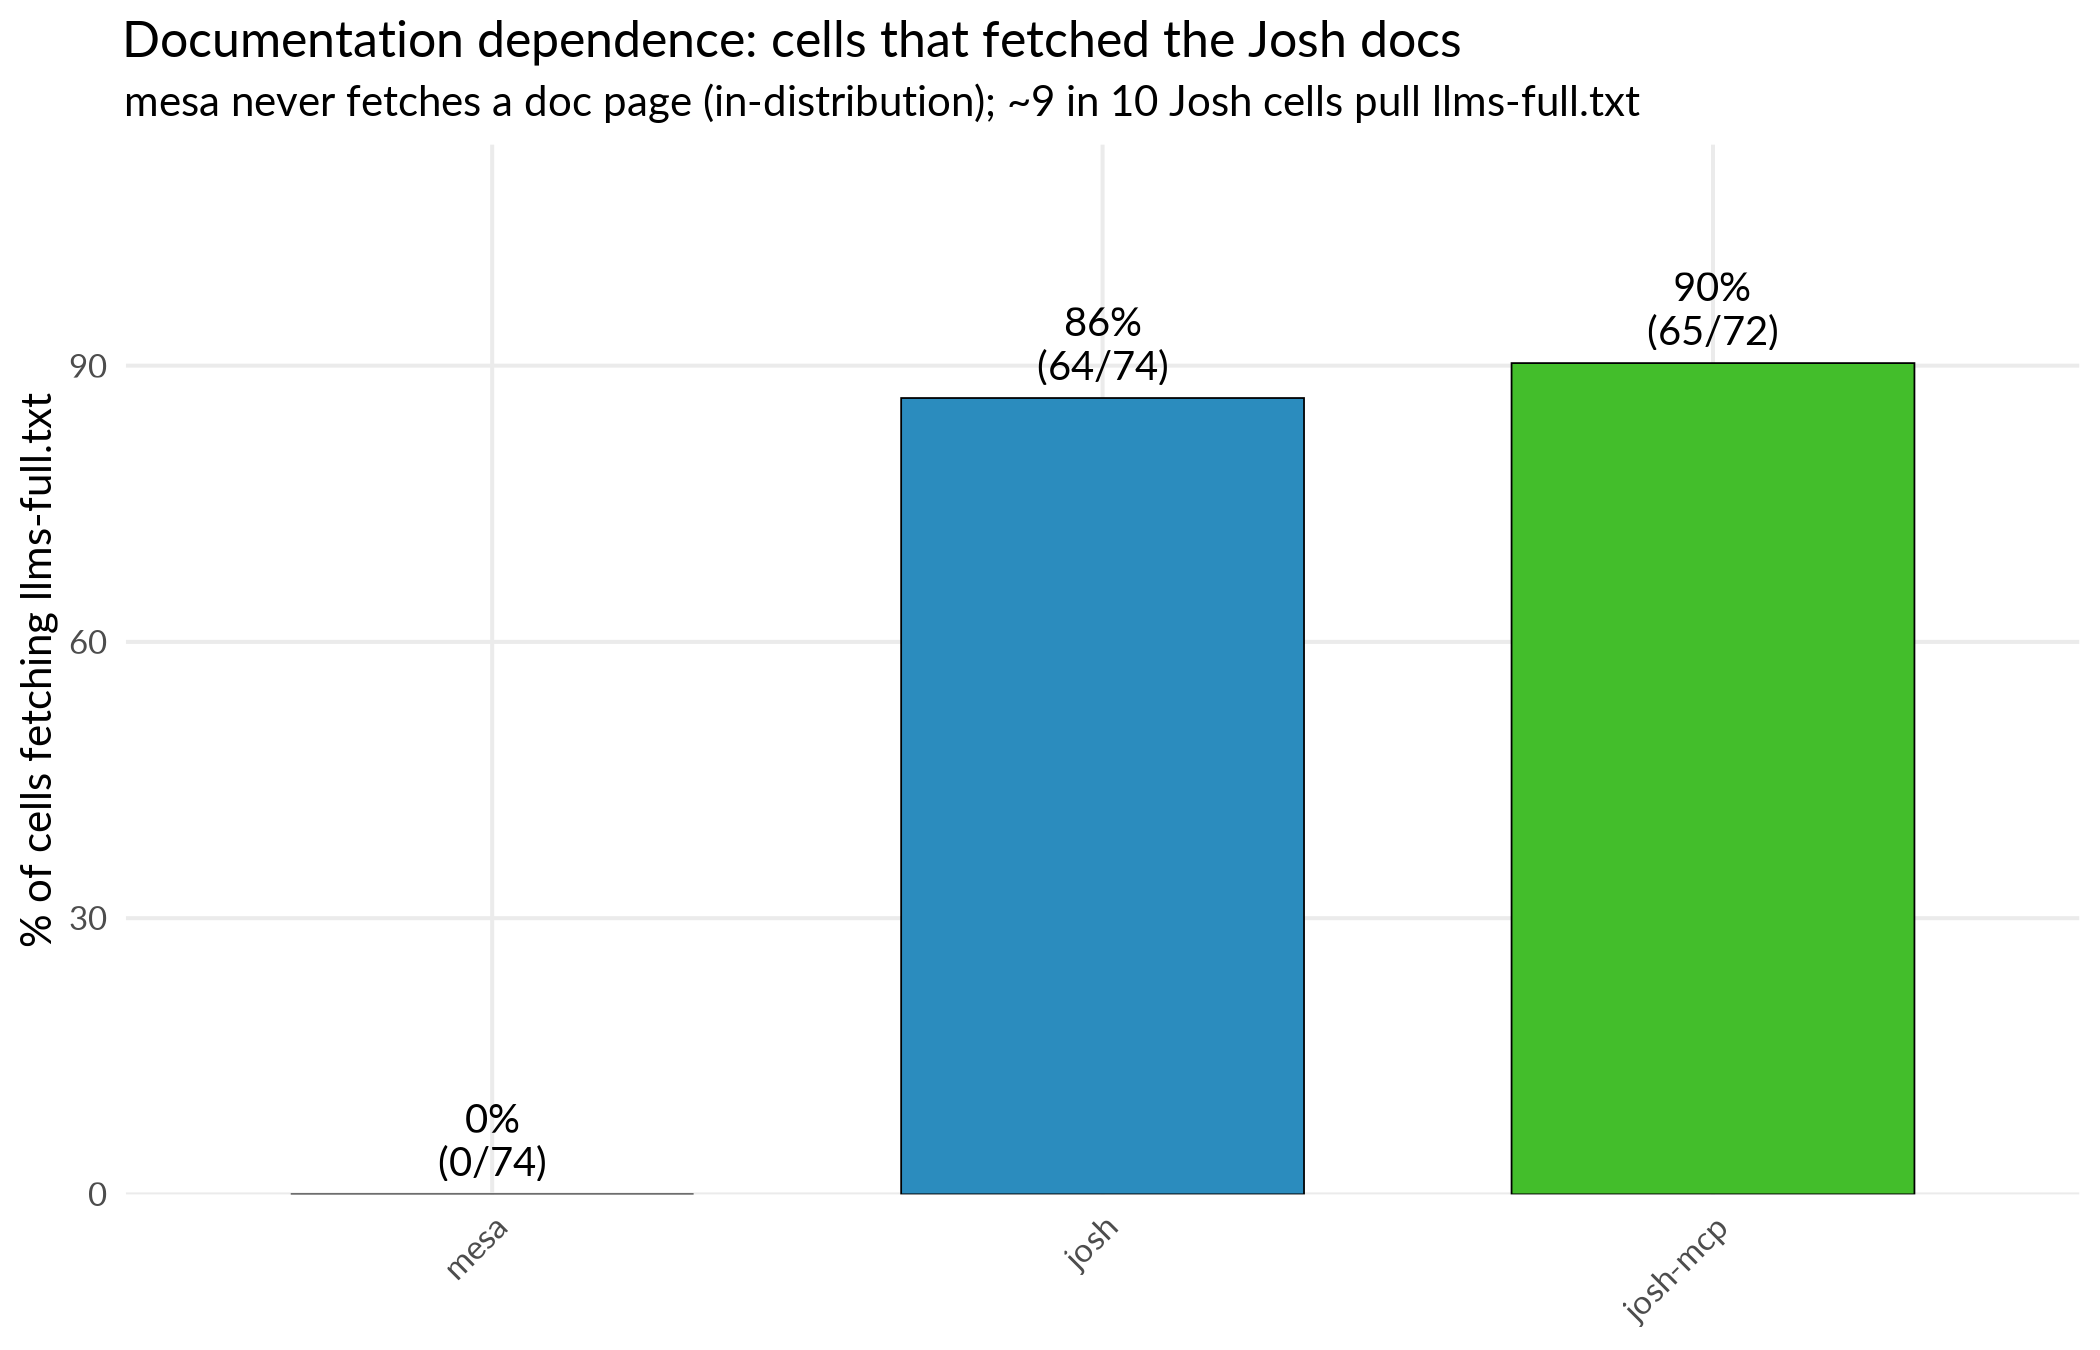

In [14]:
options(repr.plot.width = 7, repr.plot.height = 4.5)

doc_use <- df %>%
  group_by(target) %>%
  summarise(
    n_cells = n(),
    n_fetch = sum(fetched_llms_full, na.rm = TRUE),
    pct     = 100 * n_fetch / n_cells,
    .groups = "drop"
  ) %>%
  mutate(
    target = factor(target, levels = TARGET_ORDER),
    lab    = sprintf("%.0f%%\n(%d/%d)", pct, n_fetch, n_cells)
  )

p_doc <- ggplot(doc_use, aes(target, pct, fill = target)) +
  geom_col(width = 0.66, colour = "black", linewidth = 0.2) +
  geom_text(aes(label = lab), vjust = -0.25, size = 3.4,
            family = "Lato", lineheight = 0.9) +
  scale_fill_manual(values = TARGET_COLORS, guide = "none") +
  scale_y_continuous(limits = c(0, 100),
                     expand = expansion(mult = c(0, 0.14))) +
  labs(title = "Documentation dependence: cells that fetched the Josh docs",
       subtitle = "mesa never fetches a doc page (in-distribution); ~9 in 10 Josh cells pull llms-full.txt",
       x = NULL, y = "% of cells fetching llms-full.txt") +
  theme_panel()
p_doc
ggsave(file.path(OUT_DIR, "docfetch_ggplot.png"), p_doc, width = 7, height = 4.5)
ggsave(file.path(OUT_DIR, "docfetch_ggplot.pdf"), p_doc, width = 7, height = 4.5)

## Appendix — per-(model, target) summary table

In [15]:
df %>%
  # Match Panel A: exclude no_scorer rows so n reflects real attempts only.
  filter(engagement_status != "no_scorer") %>%
  group_by(model, target, .drop = FALSE) %>%
  summarise(
    n               = n(),
    did_run         = sum(did_run, na.rm = TRUE),
    substantive     = sum(substantive_conformance, na.rm = TRUE),
    fit_ok          = sum(regression_fit_ok, na.rm = TRUE),
    substantive_rate = round(mean(substantive_conformance &
                                    did_run, na.rm = TRUE), 2),
    .groups = "drop"
  )

model,target,n,did_run,substantive,fit_ok,substantive_rate
<fct>,<fct>,<int>,<int>,<int>,<int>,<dbl>
sonnet,mesa,8,8,7,8,0.88
sonnet,josh,8,8,8,8,1.00
sonnet,josh-mcp,8,7,8,7,1.00
gemma,mesa,8,3,2,0,0.25
gemma,josh,8,2,0,1,0.00
gemma,josh-mcp,8,0,2,0,0.00
kimi,mesa,8,8,8,7,1.00
kimi,josh,8,8,8,8,1.00
kimi,josh-mcp,8,4,6,4,0.75


## Composite figure (dev scratch)

Correctness (pass rate, all reps) over paired conciseness panels (source LOC / token entropy, **passing reps only**, median +/- IQR). Targets ordered mesa -> josh -> josh-mcp; Dark2 scheme: mesa `#7570b3`, josh `#1b9e77`, josh-mcp `#d95f02`. Models tier-ordered by overall pass rate. gemma/nemotron rarely passed, so they are sparse/absent in the conciseness panels.

In [16]:
# --- Composite figure candidates (dev scratch) -------------------------
# Headline composites that combine correctness + conciseness across the
# three targets, using the requested Dark2 scheme. Reuses `df` above.
suppressPackageStartupMessages({ library(patchwork) })

COMPOSITE_COLORS <- c("josh" = "#1b9e77", "josh-mcp" = "#d95f02", "mesa" = "#7570b3")
TARGET_LEVELS_C  <- c("mesa", "josh", "josh-mcp")

# full-pass flag; re-level targets for the Dark2 legend order.
dfc <- df %>%
  # Match Panel A: exclude no_scorer rows from the pass-rate denominator.
  filter(engagement_status != "no_scorer") %>%
  mutate(pass   = substantive_conformance & did_run,
         target = factor(as.character(target), levels = TARGET_LEVELS_C))

# Tier ordering: models by overall pass rate (descending).
ord_c <- dfc %>% group_by(model) %>% summarise(p = mean(pass), .groups = "drop") %>%
  arrange(desc(p)) %>% pull(model)
dfc <- dfc %>% mutate(model = factor(as.character(model), levels = ord_c))

# Correctness: bare proportion (no CI — not a statistical claim).
pr <- dfc %>% group_by(model, target, .drop = FALSE) %>%
  summarise(k = sum(pass), n = n(),
            phat = ifelse(n() > 0, sum(pass) / n(), NA_real_), .groups = "drop")

# Conciseness: passing reps only, medians.
cc <- dfc %>% filter(pass) %>% group_by(model, target, .drop = FALSE) %>%
  summarise(npass  = n(),
            loc    = median(src_loc),
            loc_lo = quantile(src_loc, 0.25), loc_hi = quantile(src_loc, 0.75),
            ent    = median(entropy_bits),
            ent_lo = quantile(entropy_bits, 0.25), ent_hi = quantile(entropy_bits, 0.75),
            .groups = "drop") %>% filter(npass > 0)

base_c <- theme_minimal(base_size = 11, base_family = "Lato") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        panel.grid.minor = element_blank(), strip.text = element_text(face = "bold"),
        legend.position = "top", plot.title = element_text(face = "bold"))
col_t <- scale_colour_manual(values = COMPOSITE_COLORS, name = "target")
fil_t <- scale_fill_manual(values = COMPOSITE_COLORS, name = "target")
dodge <- position_dodge(width = 0.6)
cat("tier order:", paste(ord_c, collapse = " > "), "\n")

tier order: glm > deepseek > sonnet > qwen > kimi > minimax > mistral > nemotron > gemma 


### C3 — correctness panel over paired conciseness panels

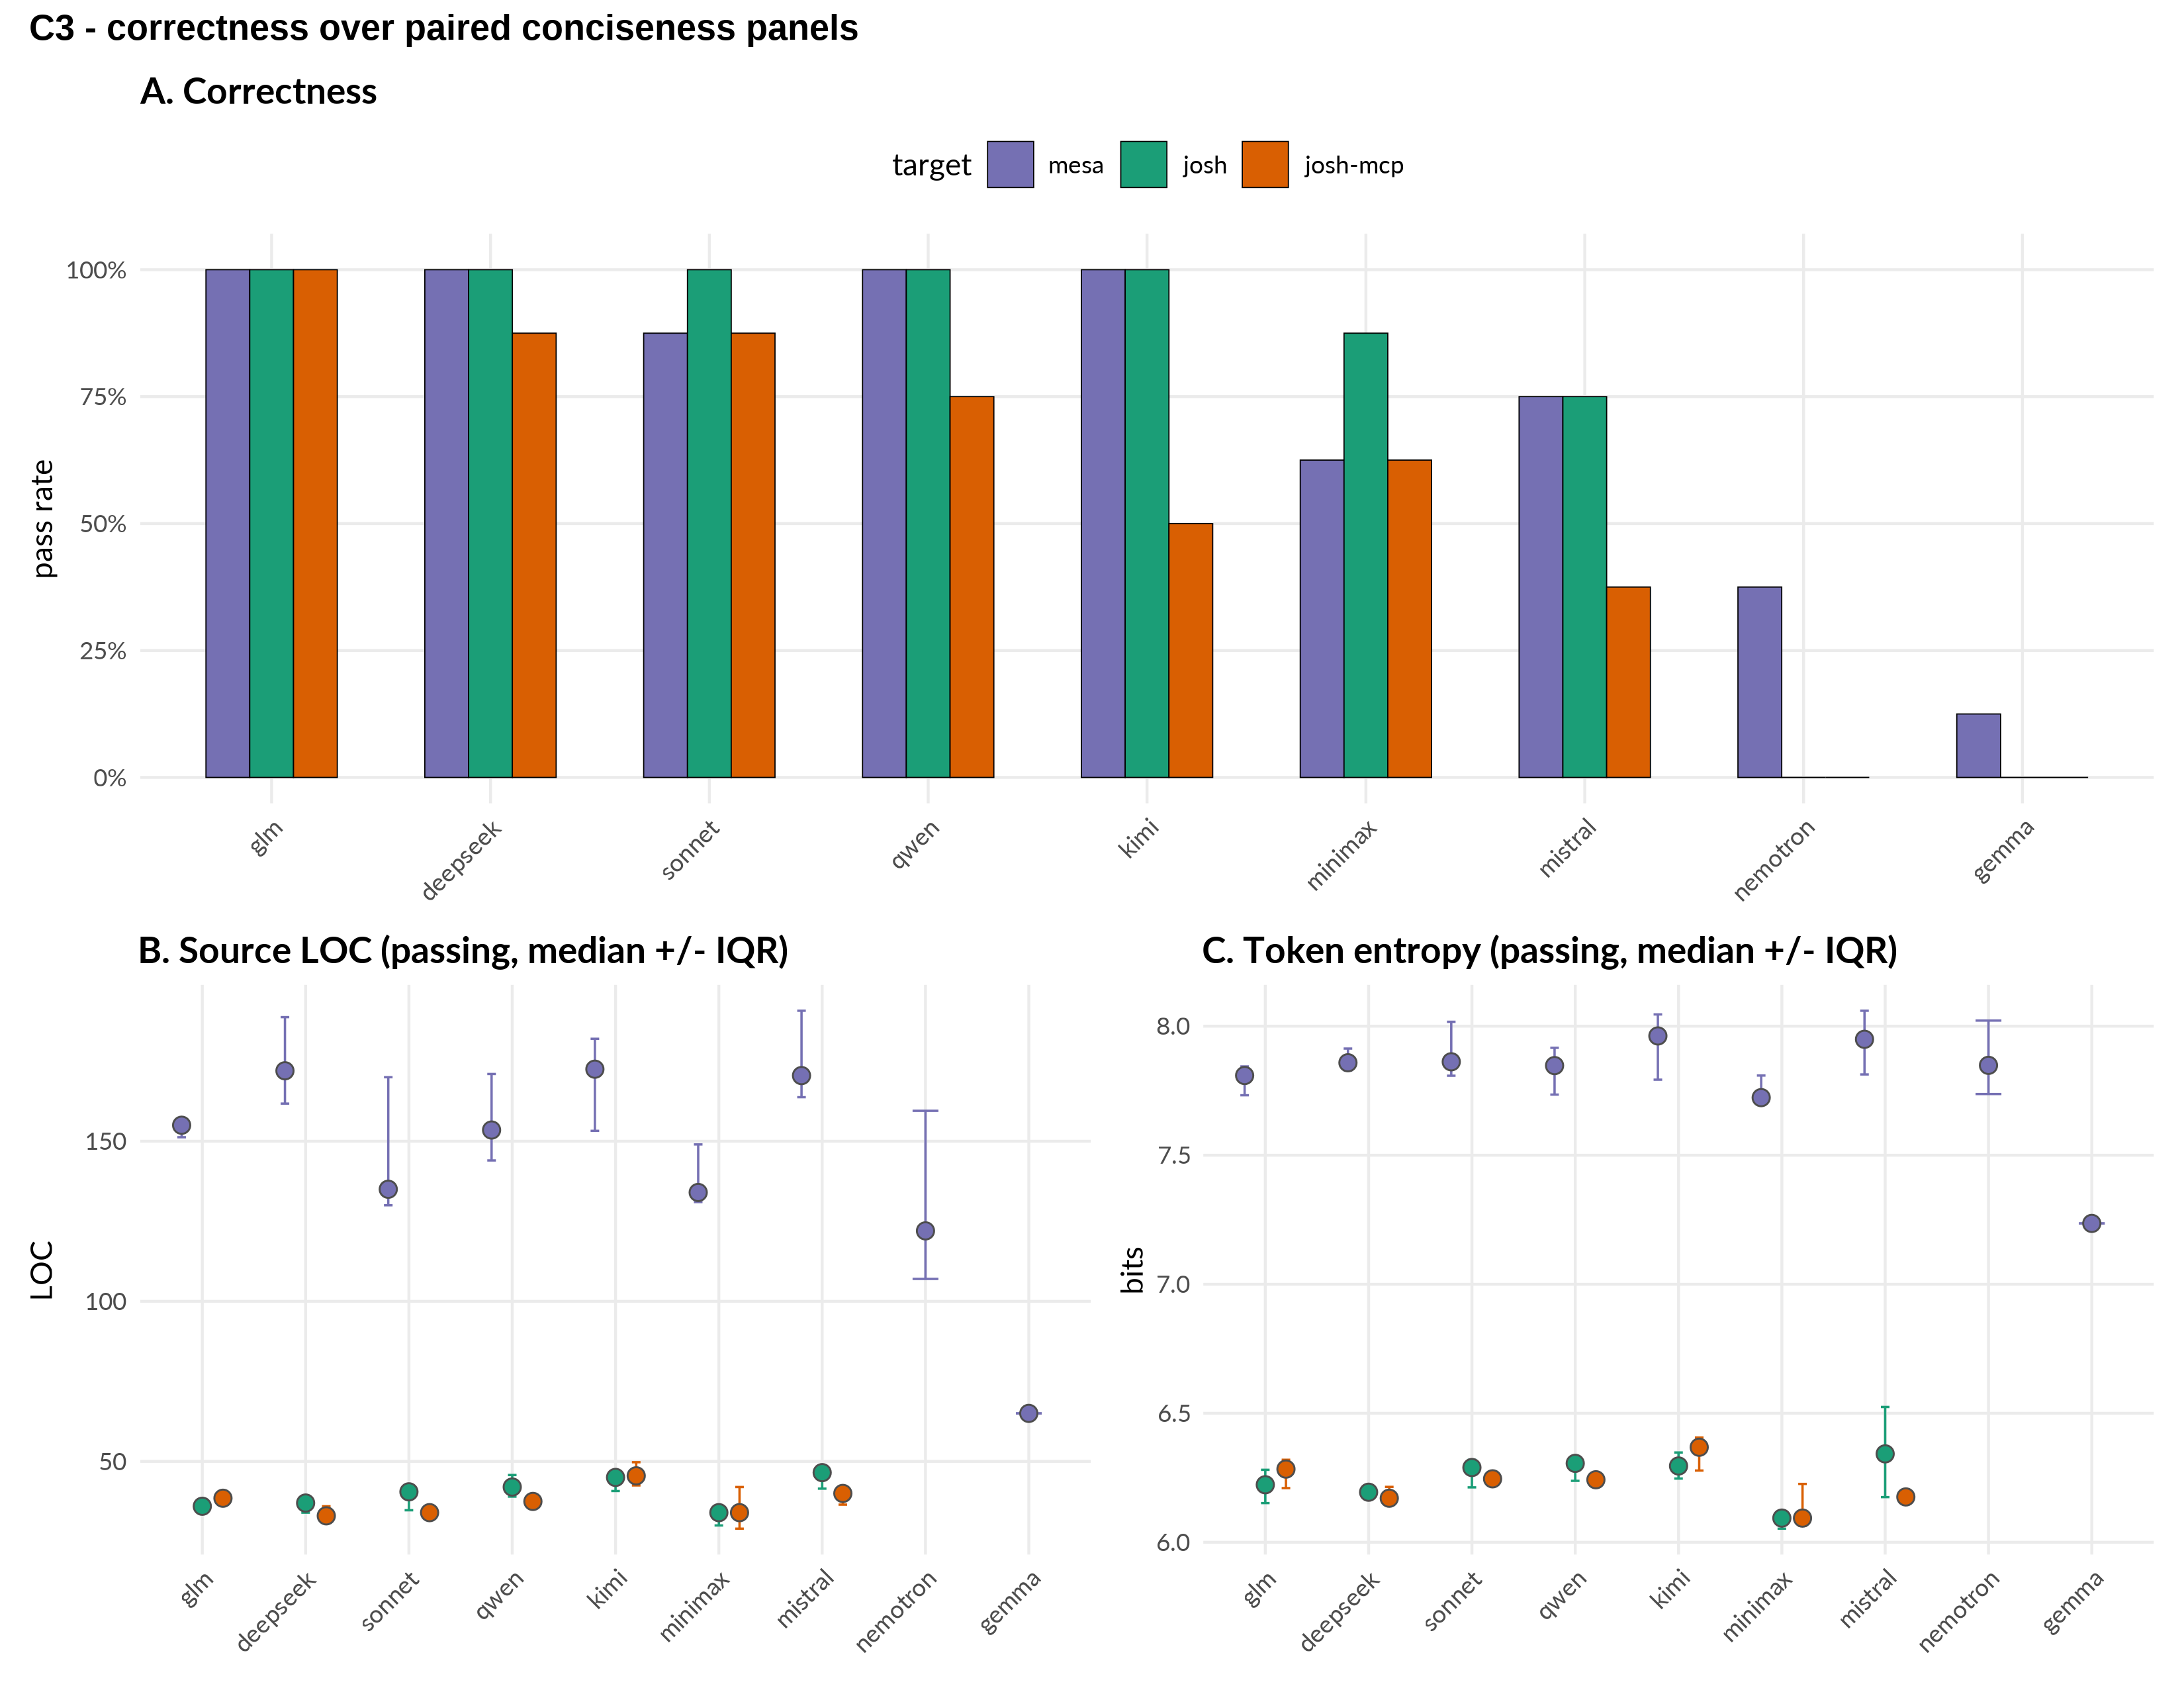

In [17]:
options(repr.plot.width = 11, repr.plot.height = 8.5)
# fill (not colour) on the point panels too, so patchwork collects ONE legend.
pA <- ggplot(pr, aes(model, phat, fill = target)) +
  geom_col(position = dodge, width = 0.6, colour = "black", linewidth = 0.2, na.rm = TRUE) +
  fil_t + scale_y_continuous(labels = percent_format(accuracy = 1), limits = c(0, 1.02)) +
  labs(title = "A. Correctness", x = NULL, y = "pass rate") + base_c
pB <- ggplot(cc, aes(model, loc, fill = target)) +
  geom_errorbar(aes(ymin = loc_lo, ymax = loc_hi, colour = target),
                position = dodge, width = 0.25, linewidth = 0.4, show.legend = FALSE) +
  geom_point(position = dodge, size = 2.6, shape = 21, colour = "grey30", show.legend = FALSE) +
  fil_t + col_t +
  labs(title = "B. Source LOC (passing, median +/- IQR)", x = NULL, y = "LOC") + base_c
pC <- ggplot(cc, aes(model, ent, fill = target)) +
  geom_errorbar(aes(ymin = ent_lo, ymax = ent_hi, colour = target),
                position = dodge, width = 0.25, linewidth = 0.4, show.legend = FALSE) +
  geom_point(position = dodge, size = 2.6, shape = 21, colour = "grey30", show.legend = FALSE) +
  fil_t + col_t +
  labs(title = "C. Token entropy (passing, median +/- IQR)", x = NULL, y = "bits") + base_c
c3 <- pA / (pB | pC) + plot_layout(guides = "collect") +
  plot_annotation(title = "C3 - correctness over paired conciseness panels",
                  theme = theme(plot.title = element_text(face = "bold", size = 13))) &
  theme(legend.position = "top")
c3
ggsave(file.path(OUT_DIR, "composite_c3.png"), c3, width = 11, height = 8.5, dpi = 300)

### C5 - all-in-one (pass rate + conciseness + 3-outcome mix)

Right panel collapses the success funnel into the one meaningful axis: **didn't complete** -> **completed, inaccurate** -> **completed & accurate**, per the verified rollup (substantive_conformance & did_run -> + regression_fit_ok). Each target's mini-heatmap is shaded in its own framework colour; intensity & the in-tile number are the rep count.

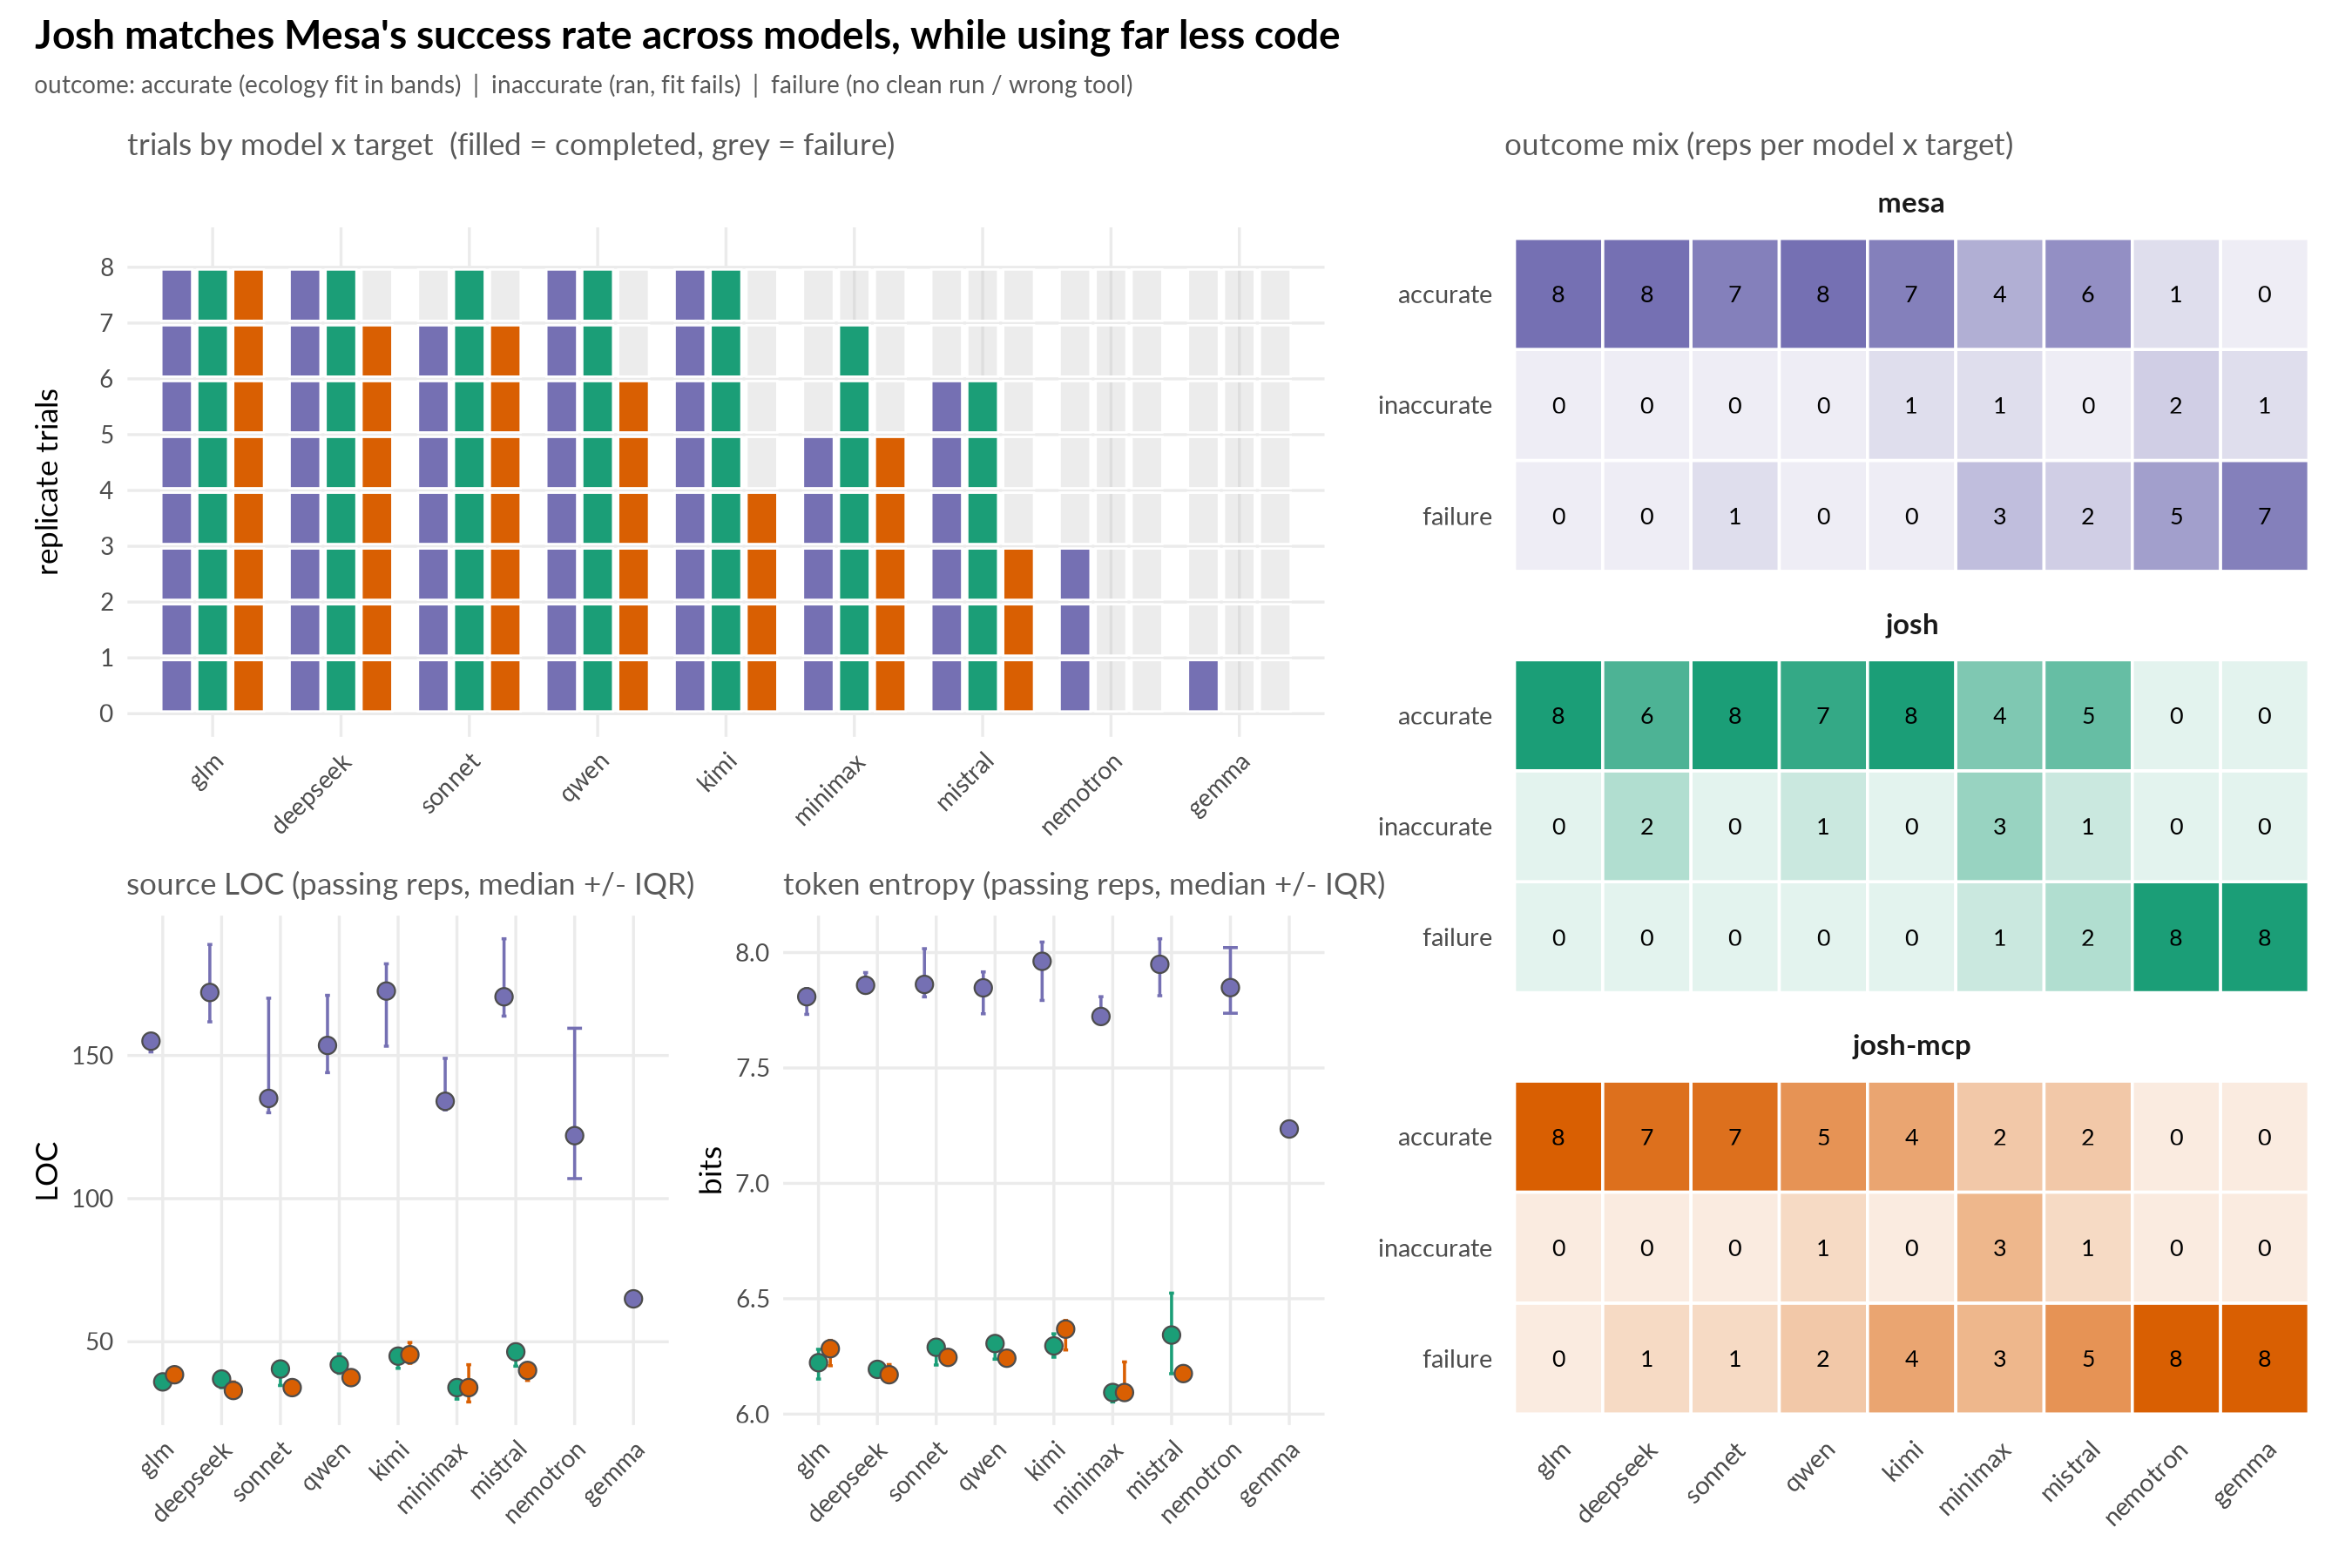

In [18]:
# Double-column IEEE figure (~7.16in). Lato via showtext (loaded above).
options(repr.plot.width = 9, repr.plot.height = 6)

OUTCOME_LEVELS <- c("failure", "inaccurate", "accurate")
outcome_df <- dfc %>%
  mutate(across(c(substantive_conformance, did_run, regression_fit_ok), as.logical),
         completed = substantive_conformance & did_run,
         outcome = factor(case_when(
           !completed                     ~ "failure",
           completed & !regression_fit_ok ~ "inaccurate",
           TRUE                           ~ "accurate"),
           levels = OUTCOME_LEVELS)) %>%
  count(model, target, outcome, .drop = FALSE)

# white background, no minor grid (matches the reference figure)
base5 <- theme_minimal(base_size = 8.5, base_family = "Lato") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        panel.grid.minor = element_blank(),
        panel.background = element_rect(fill = "white", colour = NA),
        plot.background  = element_rect(fill = "white", colour = NA),
        strip.text = element_text(face = "bold", size = 8),
        legend.position = "none",
        plot.title = element_text(colour = "grey35", size = 8.5))

# A: every replicate is one block. Completed reps in the framework colour;
# failures as faint grey blocks so 0/5 cells (gemma, nemotron) stay visible.
seg_w <- 0.12; toff <- 0.28; gap <- 0.04
panelA_long <- pr %>%
  tidyr::uncount(n, .id = "seg") %>%
  mutate(status = ifelse(seg <= k, "completed", "failure"),
         mi  = as.integer(model),
         off = (as.integer(target) - 2) * toff,
         xmin = mi + off - seg_w, xmax = mi + off + seg_w,
         ymin = seg - 1 + gap,    ymax = seg - gap,
         fillc = ifelse(status == "completed",
                        unname(COMPOSITE_COLORS[as.character(target)]), "grey75"),
         a     = ifelse(status == "completed", 1, 0.30))
nmax <- max(pr$n)
pA5 <- ggplot(panelA_long) +
  geom_rect(aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax,
                fill = fillc, alpha = a), colour = "white", linewidth = 0.3) +
  scale_fill_identity() + scale_alpha_identity() +
  scale_x_continuous(breaks = seq_along(levels(pr$model)), labels = levels(pr$model),
                     expand = expansion(mult = 0.03)) +
  scale_y_continuous(breaks = 0:nmax, limits = c(0, nmax + 0.3)) +
  labs(title = "trials by model x target  (filled = completed, grey = failure)",
       x = NULL, y = "replicate trials") + base5

pB5 <- ggplot(cc, aes(model, loc, fill = target)) +
  geom_errorbar(aes(ymin = loc_lo, ymax = loc_hi, colour = target),
                position = dodge, width = 0.25, linewidth = 0.4) +
  geom_point(position = dodge, size = 2, shape = 21, colour = "grey30") +
  fil_t + col_t + labs(title = "source LOC (passing reps, median +/- IQR)",
                       x = NULL, y = "LOC") + base5

pC5 <- ggplot(cc, aes(model, ent, fill = target)) +
  geom_errorbar(aes(ymin = ent_lo, ymax = ent_hi, colour = target),
                position = dodge, width = 0.25, linewidth = 0.4) +
  geom_point(position = dodge, size = 2, shape = 21, colour = "grey30") +
  fil_t + col_t + labs(title = "token entropy (passing reps, median +/- IQR)",
                       x = NULL, y = "bits") + base5

# D: outcome mix, framework-coloured; category labels on the LEFT (padded).
# Doubles as the target colour key.
pBreak <- ggplot(outcome_df, aes(model, outcome, fill = target, alpha = n)) +
  geom_tile(colour = "white", linewidth = 0.4) +
  geom_text(aes(label = n), alpha = 1, size = 2.3) +
  facet_wrap(~ target, ncol = 1) +
  scale_fill_manual(values = COMPOSITE_COLORS, guide = "none") +
  scale_alpha(range = c(0.12, 1), guide = "none") +
  labs(title = "outcome mix (reps per model x target)", x = NULL, y = NULL) +
  base5 + theme(panel.grid = element_blank(),
                axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
                axis.text.y = element_text(size = 7),
                plot.margin = margin(4, 4, 4, 10))

design <- "
AAD
BCD
"
c5 <- pA5 + pB5 + pC5 + pBreak +
  plot_layout(design = design, widths = c(1, 1, 1.5)) +
  plot_annotation(
    title = "Josh matches Mesa's success rate across models, while using far less code",
    subtitle = "outcome: accurate (ecology fit in bands)  |  inaccurate (ran, fit fails)  |  failure (no clean run / wrong tool)",
    theme = theme(plot.title = element_text(face = "bold", size = 11, family = "Lato"),
                  plot.subtitle = element_text(size = 6.8, colour = "grey35", family = "Lato"),
                  plot.background = element_rect(fill = "white", colour = NA))) &
  theme(legend.position = "none",
        plot.background = element_rect(fill = "white", colour = NA))
c5
ggsave(file.path(OUT_DIR, "composite_c5.pdf"), c5, width = 7.16, height = 4.8)
ggsave(file.path(OUT_DIR, "composite_c5.png"), c5, width = 7.16, height = 4.8, dpi = 300, bg = "white")

## Conformance cross-check: mechanical vs fuzzy Q1

C5's `completed` gate uses **substantive** conformance (`target_conformance` AND Q1='yes'). Before committing to that over mechanical-only, isolate the cells where the mechanical grep / `josh validate` and the LLM judge's Q1 **disagree**, and read the judge's reasoning to decide who to trust.

In [19]:
# Cells where mechanical target_conformance and fuzzy Q1 disagree.
#   mech=PASS + Q1 in {no, partial} -> judge says "framework not load-bearing"
#   mech=FAIL + Q1 = yes            -> judge says "it did use it" (grep missed it)
#   mech=PASS + parse_error         -> no usable judge verdict (fail-closed)
xcheck <- df %>%
  mutate(mech = as.logical(target_conformance),
         q1   = fuzzy_q1_answer,
         parse_error = as.logical(fuzzy_parse_error)) %>%
  filter((mech & q1 %in% c("no", "partial")) |
         (!mech & q1 == "yes") |
         (mech & parse_error %in% TRUE)) %>%
  arrange(target, model, rep_idx)

cat(sprintf("Disagreement cells: %d of %d\n\n", nrow(xcheck), nrow(df)))
if (nrow(xcheck) > 0) {
  xcheck %>%
    mutate(kind = case_when(
      mech & q1 %in% c("no", "partial") ~ "mech=PASS, Q1=no/partial (sidecar?)",
      !mech & q1 == "yes"               ~ "mech=FAIL, Q1=yes (grep missed?)",
      TRUE                              ~ "mech=PASS, judge parse_error")) %>%
    count(target, kind) %>% as.data.frame() %>% print()

  wrapj <- function(x, w = 88, ind = "       ") {
    if (length(x) == 0 || is.na(x) || !nzchar(x)) return("(none)")
    paste(strwrap(x, width = w), collapse = paste0("\n", ind))
  }
  cat("\n=== Per-cell judge text (read to adjudicate) ===\n")
  for (i in seq_len(nrow(xcheck))) {
    r <- xcheck[i, ]
    cat(sprintf("\n[mech=%s | Q1=%s%s] %s / %s / r%s\n  %s\n",
                ifelse(r$mech, "PASS", "FAIL"),
                ifelse(is.na(r$q1), "NA", r$q1),
                ifelse(isTRUE(r$parse_error), " | parse_error", ""),
                r$model, r$target, r$rep_idx, r$run_id))
    cat("  Q1:", wrapj(r$fuzzy_q1_justification), "\n")
    cat("  Q2:", wrapj(r$fuzzy_q2_observations), "\n")
  }
} else {
  cat("No disagreements: mechanical and Q1 agree on every cell.\n")
}

Disagreement cells: 11 of 220



    target                                kind n
1     mesa mech=PASS, Q1=no/partial (sidecar?) 3
2     josh    mech=FAIL, Q1=yes (grep missed?) 2
3 josh-mcp    mech=FAIL, Q1=yes (grep missed?) 4
4 josh-mcp mech=PASS, Q1=no/partial (sidecar?) 2

=== Per-cell judge text (read to adjudicate) ===

[mech=PASS | Q1=no] gemma / mesa / r0
  headline-rerep-202606020525-gemma-mesa-r0
  Q1: The delivered code leaves `run_simulation` empty and never actually instantiates or
       runs a Mesa model, so the named framework never drives the ecology logic. 
  Q2: During Todo 6 the agent realised they had broken the working stub and then spiralled
       for pages narrating plans to rewrite `simulation.py`, repeatedly listing intended
       imports without producing code. They never recovered from that loop, leaving the file
       with placeholder patch wiring and an unimplemented `run_simulation`. 

[mech=PASS | Q1=no] gemma / mesa / r1
  headline-rerep-202606020525-gemma-mesa-r1
  Q1: The CSVs ar

## Fuzzy-judge readout — Q1 / Q2 / Q3 per cell

Per-cell verdicts from the in-Pod judge: **Q1** (did the agent use the named framework?), **Q2** (where did it get stuck? — free text), **Q3** (does `./run.sh` carry preprocess + 100 reps + 2024..2123?). The qualitative **Q2** notes are the main reason to keep this readout. Cells without judge data are skipped.

In [20]:
# Per-cell Q1/Q2/Q3 fuzzy-judge readout.
.g <- function(a) { m <- c(yes="\u2713", no="\u2717", partial="~")
  if (!is.na(a) && a %in% names(m)) unname(m[a]) else "?" }
.wrap <- function(lbl, x) {
  if (is.na(x) || !nzchar(trimws(x))) x <- "(none)"
  cat(strwrap(paste0("   ", lbl, ": ", x), width = 96, exdent = 7), sep = "\n"); cat("\n")
}
fz <- df %>%
  filter(!is.na(fuzzy_q1_answer) & fuzzy_q1_answer != "") %>%
  mutate(.m = match(model, MODEL_ORDER), .t = match(target, TARGET_ORDER),
         .q3 = match(fuzzy_q3_answer, c("yes", "partial", "no"))) %>%
  arrange(.m, .t, .q3, run_id)
cat(sprintf("cells with fuzzy data: %d / %d\n\n", nrow(fz), nrow(df)))
for (i in seq_len(nrow(fz))) {
  r <- fz[i, ]
  fit_ok <- if ("regression_fit_ok" %in% names(r)) isTRUE(as.logical(r$regression_fit_ok)) else NA
  cat(sprintf("[Q1 %s] [Q3 %s] %-8s %-8s did_run=%s fit_ok=%s sim=%.0fs\n",
              .g(r$fuzzy_q1_answer), .g(r$fuzzy_q3_answer), r$model, r$target,
              ifelse(isTRUE(as.logical(r$did_run)), "Y", "N"),
              ifelse(is.na(fit_ok), "?", ifelse(fit_ok, "Y", "N")),
              ifelse(is.na(r$sim_wall_seconds), 0, r$sim_wall_seconds)))
  .wrap("Q1", r$fuzzy_q1_justification)
  .wrap("Q2", r$fuzzy_q2_observations)
  .wrap("Q3", r$fuzzy_q3_justification)
  cat("\n")
}


cells with fuzzy data: 210 / 220



[Q1 ✓] [Q3 ✓] sonnet   mesa     did_run=Y fit_ok=Y sim=49s
Q1: `simulation.py` subclasses `mesa.Model` and `mesa.Agent`, with all growth logic running
       inside the Mesa step loop.

Q2: The transcript shows each todo completed in a single pass without detours or repeated
       edits. After wiring in the growth equation the agent ran `./run.sh` and a quick pandas
       check, with no debugging loops or evident confusion.

Q3: `run.sh` just creates `output/` and runs `simulation.py`, which loads the netCDF climate
       data, iterates over the requested replicates, and advances `SIM_YEARS` 2024–2123 for
       each model instance.


[Q1 ✓] [Q3 ✓] sonnet   mesa     did_run=Y fit_ok=Y sim=105s
Q1: simulate.py builds Mesa Model and Agent subclasses and runs the growth dynamics entirely
       through that framework.

Q2: Each todo in the transcript progressed smoothly with no repeated errors or detours. The
       agents implemented the plan, wrote the Mesa code, and validated the ou

## Conciseness: how much less code did Josh generate?

Quantifies the LOC (and token-entropy) reduction of Josh / josh-mcp vs Mesa, **over completed cells only** (`substantive_conformance & did_run`) — LOC of a broken/empty implementation is meaningless. Prints sentence-ready figures for the results stub.

In [21]:
# Completed cells only (pass = substantive_conformance & did_run, from prep cell).
comp <- dfc %>% filter(pass)

# Per-target medians + reduction vs Mesa.
loc_summary <- comp %>%
  group_by(target) %>%
  summarise(n_completed = n(),
            loc_median = median(src_loc),  loc_mean = round(mean(src_loc), 1),
            ent_median = round(median(entropy_bits), 2),
            .groups = "drop")
mesa_loc <- loc_summary$loc_median[loc_summary$target == "mesa"]
mesa_ent <- loc_summary$ent_median[loc_summary$target == "mesa"]
loc_summary <- loc_summary %>%
  mutate(loc_fold_vs_mesa = round(mesa_loc / loc_median, 1),
         loc_pct_fewer    = round(100 * (1 - loc_median / mesa_loc)),
         ent_below_mesa   = round(mesa_ent - ent_median, 2))
cat("=== Per-target (completed cells) ===\n")
print(as.data.frame(loc_summary))

# Pooled DSL (josh + josh-mcp) vs Mesa.
dsl <- comp %>% filter(target %in% c("josh", "josh-mcp"))
mes <- comp %>% filter(target == "mesa")
dsl_loc <- median(dsl$src_loc); mes_loc <- median(mes$src_loc)
dsl_ent <- median(dsl$entropy_bits); mes_ent2 <- median(mes$entropy_bits)
cat(sprintf("\n=== Pooled DSL (josh + josh-mcp) vs Mesa ===\n"))
cat(sprintf("median LOC: DSL %.0f vs Mesa %.0f  -> %.1fx fewer (%.0f%% fewer)\n",
            dsl_loc, mes_loc, mes_loc/dsl_loc, 100*(1 - dsl_loc/mes_loc)))
cat(sprintf("median entropy: DSL %.2f vs Mesa %.2f bits (%.2f bits lower)\n",
            dsl_ent, mes_ent2, mes_ent2 - dsl_ent))

# Per-model fold (models completing in both arms), to back "consistent across models".
pm <- comp %>% group_by(model, target) %>%
  summarise(loc = median(src_loc), n = n(), .groups = "drop") %>%
  select(model, target, loc) %>%
  tidyr::pivot_wider(names_from = target, values_from = loc)
names(pm) <- make.names(names(pm))   # josh-mcp -> josh.mcp
pm <- pm %>% mutate(josh_fold = round(mesa / josh, 1),
                    mcp_fold  = round(mesa / josh.mcp, 1))
cat("\n=== Per-model median LOC by target, and Mesa/Josh fold (NA = no completed cells) ===\n")
print(as.data.frame(pm))

# Sentence-ready lines for the stub.
jl <- loc_summary$loc_median[loc_summary$target == "josh"]
ml <- mesa_loc
cat(sprintf("\nSTUB: Josh median %.0f LOC vs Mesa %.0f LOC (%.1fx fewer, %.0f%% fewer).\n",
            jl, ml, ml/jl, 100*(1 - jl/ml)))


# --- Percentage range based on AVERAGES (mean LOC), per model ---
pmA <- comp %>% group_by(model, target) %>%
  summarise(loc = mean(src_loc), .groups = "drop") %>%
  tidyr::pivot_wider(names_from = target, values_from = loc)
names(pmA) <- make.names(names(pmA))     # josh-mcp -> josh.mcp
pmA <- pmA %>% mutate(josh_pct = 100 * (1 - josh / mesa),
                      mcp_pct  = 100 * (1 - josh.mcp / mesa))
cat("\n=== Mean-LOC % fewer than Mesa, per model ===\n")
print(as.data.frame(pmA %>% mutate(across(c(josh, josh.mcp, mesa), ~ round(.x, 1)),
                                   across(c(josh_pct, mcp_pct), ~ round(.x)))))
rng <- range(c(pmA$josh_pct, pmA$mcp_pct), na.rm = TRUE)
jrng <- range(pmA$josh_pct, na.rm = TRUE)
cat(sprintf("\nSTUB (averages): per model, Josh uses %.0f-%.0f%% fewer lines than Mesa;\n",
            jrng[1], jrng[2]))
cat(sprintf("            DSL (josh + josh-mcp) spans %.0f-%.0f%% fewer across models.\n",
            rng[1], rng[2]))
cat(sprintf("Pooled mean LOC: DSL %.1f vs Mesa %.1f  -> %.0f%% fewer.\n",
            mean(dsl$src_loc), mean(mes$src_loc),
            100 * (1 - mean(dsl$src_loc) / mean(mes$src_loc))))


# --- Token entropy reduction based on AVERAGES (mean bits), per model ---
pmE <- comp %>% group_by(model, target) %>%
  summarise(ent = mean(entropy_bits), .groups = "drop") %>%
  tidyr::pivot_wider(names_from = target, values_from = ent)
names(pmE) <- make.names(names(pmE))
pmE <- pmE %>% mutate(josh_pct = 100 * (1 - josh / mesa),
                      josh_bits = mesa - josh,
                      mcp_pct  = 100 * (1 - josh.mcp / mesa),
                      mcp_bits = mesa - josh.mcp)
cat("\n=== Mean token entropy (bits) by target, and reduction vs Mesa, per model ===\n")
print(as.data.frame(pmE %>% mutate(across(c(josh, josh.mcp, mesa, josh_bits, mcp_bits), ~ round(.x, 2)),
                                   across(c(josh_pct, mcp_pct), ~ round(.x)))))
pct_rng  <- range(c(pmE$josh_pct,  pmE$mcp_pct),  na.rm = TRUE)
bits_rng <- range(c(pmE$josh_bits, pmE$mcp_bits), na.rm = TRUE)
cat(sprintf("\nSTUB (averages): the DSL lowers token entropy by %.0f-%.0f%% (%.2f-%.2f bits) vs Mesa across models.\n",
            pct_rng[1], pct_rng[2], bits_rng[1], bits_rng[2]))
cat(sprintf("Pooled mean entropy: DSL %.2f vs Mesa %.2f bits  -> %.2f bits lower (%.0f%% lower).\n",
            mean(dsl$entropy_bits), mean(mes$entropy_bits),
            mean(mes$entropy_bits) - mean(dsl$entropy_bits),
            100 * (1 - mean(dsl$entropy_bits) / mean(mes$entropy_bits))))

=== Per-target (completed cells) ===


    target n_completed loc_median loc_mean ent_median loc_fold_vs_mesa
1     mesa          54      159.0    158.7       7.84              1.0
2     josh          53       39.0     39.2       6.24              4.1
3 josh-mcp          40       36.5     38.2       6.23              4.4
  loc_pct_fewer ent_below_mesa
1             0           0.00
2            75           1.60
3            77           1.61



=== Pooled DSL (josh + josh-mcp) vs Mesa ===


median LOC: DSL 37 vs Mesa 159  -> 4.3x fewer (77% fewer)


median entropy: DSL 6.23 vs Mesa 7.84 bits (1.61 bits lower)


...

Pooled mean LOC: DSL 38.7 vs Mesa 158.7  -> 76% fewer.



=== Mean token entropy (bits) by target, and reduction vs Mesa, per model ===


     model mesa josh josh.mcp josh_pct josh_bits mcp_pct mcp_bits
1      glm 7.79 6.22     6.26       20      1.58      20     1.53
2 deepseek 7.89 6.20     6.20       21      1.69      21     1.69
3   sonnet 7.91 6.26     6.29       21      1.65      21     1.62
4     qwen 7.81 6.30     6.25       19      1.51      20     1.56
5     kimi 7.93 6.29     6.32       21      1.64      20     1.61
6  minimax 7.76 6.09     6.12       21      1.66      21     1.63
7  mistral 7.91 6.38     6.19       19      1.53      22     1.72
8 nemotron 7.89   NA       NA       NA        NA      NA       NA
9    gemma 7.24   NA       NA       NA        NA      NA       NA



STUB (averages): the DSL lowers token entropy by 19-22% (1.51-1.72 bits) vs Mesa across models.


Pooled mean entropy: DSL 6.24 vs Mesa 7.85 bits  -> 1.61 bits lower (20% lower).
